## **1. Setup**

In [49]:
!pip install -q tensorflow scikit-learn xgboost pandas numpy matplotlib seaborn joblib

import warnings
warnings.filterwarnings('ignore')

print("✓ All packages installed!")

✓ All packages installed!


In [50]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import joblib

# Sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# XGBoost
import xgboost as xgb

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"\n✓ All libraries imported!")

TensorFlow version: 2.19.0
Pandas version: 2.2.2
NumPy version: 2.0.2

✓ All libraries imported!


## **2. Load & Explore Data**

In [51]:
from google.colab import files
print("Please upload csv file:")
uploaded = files.upload()

uploaded_filename = list(uploaded.keys())[0]
print(f"\nFile uploaded: {uploaded_filename}")

df = pd.read_csv(uploaded_filename)
print(f"Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

df['date'] = pd.to_datetime(df['tahun'].astype(str) + '-' + df['bulan'].astype(str).str.zfill(2) + '-01')

print(f"Date range: {df['tahun'].min()}-{df['bulan'].min():02d} to {df['tahun'].max()}-{df['bulan'].max():02d}")
print(f"Unique commodities: {df['kode_komoditi'].nunique()}")

print(f"\nFiltering commodities...")
print(f"Before filter: {len(df):,} rows")
print(f"Zero bahan_makanan records: {(df['bahan_makanan'] == 0).sum():,}")

df_clean = df[df['bahan_makanan'] > 0].copy()

print(f"After filter: {len(df_clean):,} rows ({len(df_clean)/len(df)*100:.1f}%)")
print(f"Remaining commodities: {df_clean['kode_komoditi'].nunique()}")

print(f"\nSample data (Beras):")
print(df_clean[df_clean['nama_komoditi'] == 'Beras'].head(10)[['tahun', 'bulan', 'nama_komoditi', 'bahan_makanan', 'kalori_per_capita_per_day']])

df = df_clean
print(f"\nReady for modeling with {len(df):,} records")

Please upload csv file:


Saving nbm_processed_fixed_v3.csv to nbm_processed_fixed_v3 (1).csv

File uploaded: nbm_processed_fixed_v3 (1).csv
Data loaded: 48,696 rows, 58 columns
Date range: 1993-01 to 2024-12
Unique commodities: 114

Filtering commodities...
Before filter: 48,696 rows
Zero bahan_makanan records: 876
After filter: 47,820 rows (98.2%)
Remaining commodities: 112

Sample data (Beras):
     tahun  bulan nama_komoditi  bahan_makanan  kalori_per_capita_per_day
408   1993      1         Beras     19039.2561                1004.194886
409   1993      2         Beras     21596.1372                1139.053460
410   1993      3         Beras     23075.3250                1217.070837
411   1993      4         Beras     22293.4689                1175.833097
412   1993      5         Beras     19990.1628                1054.348928
413   1993      6         Beras     21469.3497                1132.366258
414   1993      7         Beras     19736.5878                1040.974523
415   1993      8         Beras  

ANALISIS KOMODITI BERDASARKAN KONTRIBUSI KALORI

TOP 20 KOMODITI - KONTRIBUTOR UTAMA KALORI

No   Kode     Nama Komoditi                    Avg Kalori Contribution Tier                
----------------------------------------------------------------------------------------------------
1    102      Beras                             1060.04 kkal       8.78% TIER 1 - MAYOR      
2    1003     Minyak Sawit                       496.04 kkal       4.23% TIER 1 - MAYOR      
3    506      Mangga                             457.96 kkal       4.02% TIER 1 - MAYOR      
4    504      Durian                             444.18 kkal       4.22% TIER 1 - MAYOR      
5    701      Daging Sapi                        429.52 kkal       4.29% TIER 1 - MAYOR      
6    511      Salak                              420.25 kkal       3.58% TIER 1 - MAYOR      
7    902      Susu Impor                         419.55 kkal       3.47% TIER 1 - MAYOR      
8    605      Kentang                            341.54 

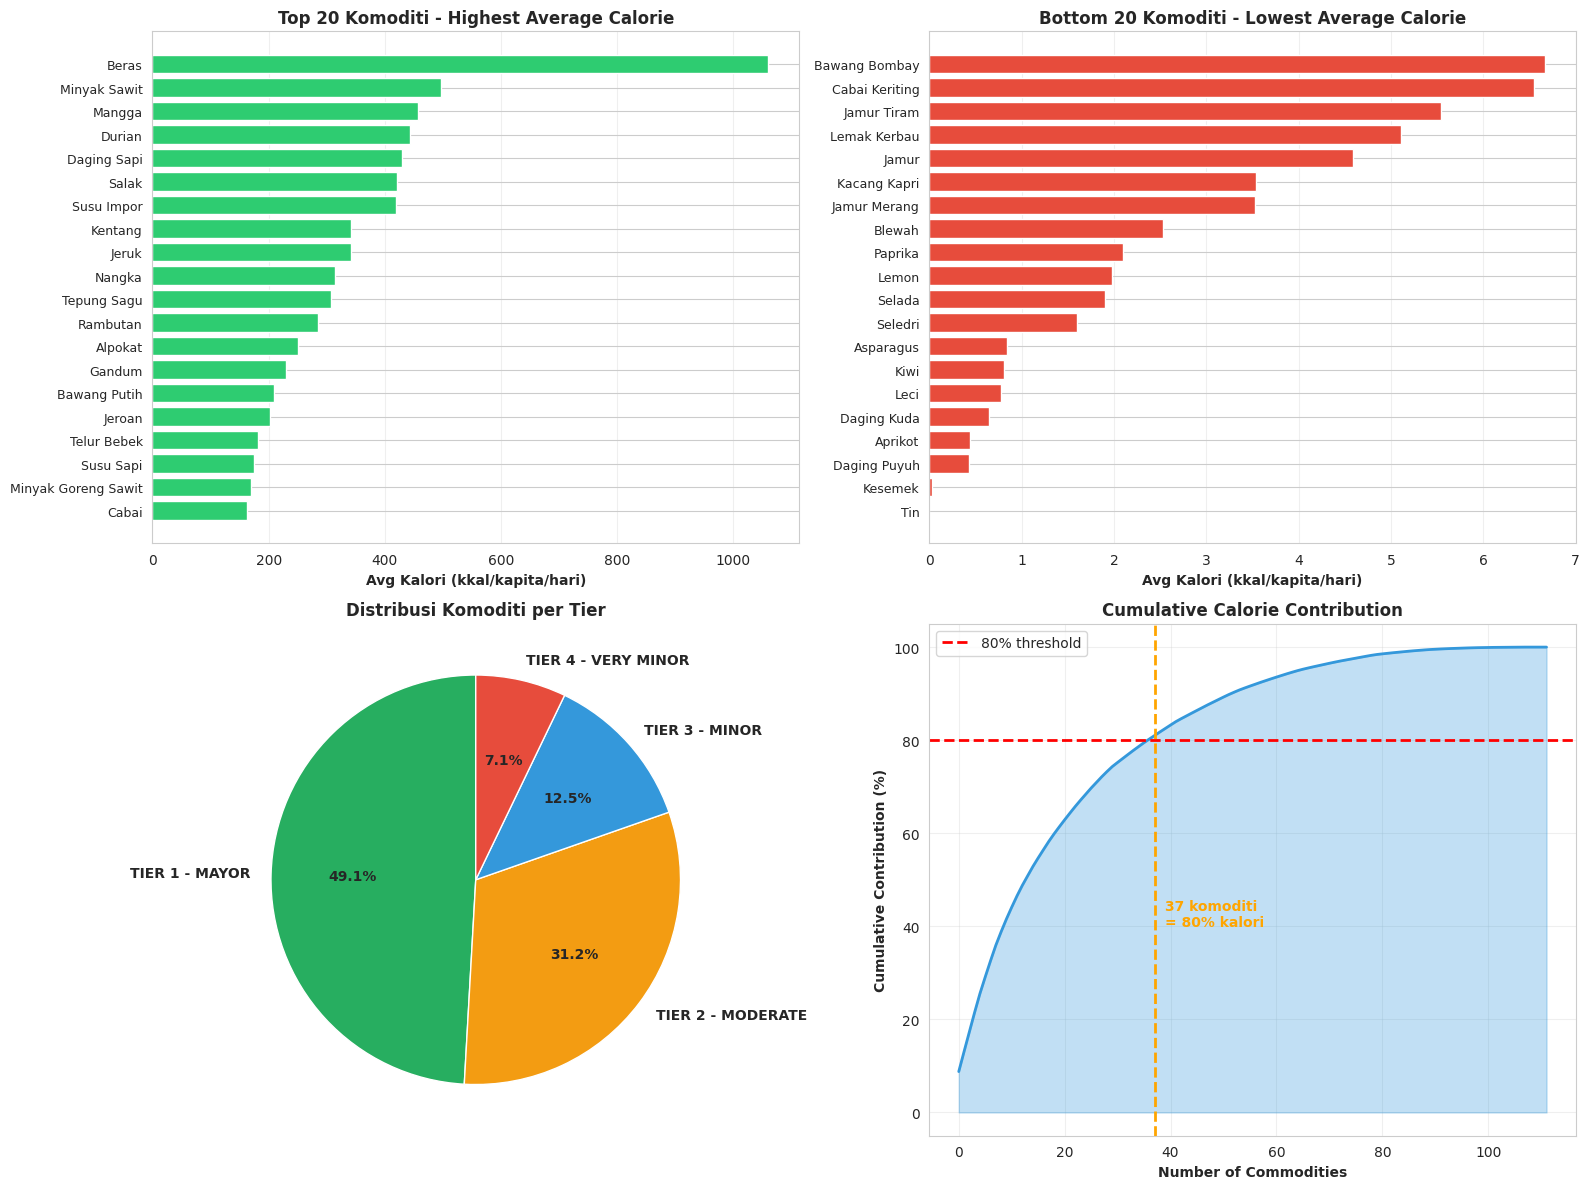


✓ Visualisasi disimpan: komoditi_analysis.png

KESIMPULAN ANALISIS

📊 FINDINGS:
   • 82 komoditi berkontribusi 98.7% total kalori
   • 16 komoditi hanya berkontribusi 0.2% total kalori
   • 37 komoditi teratas = 80% total kalori nasional

🎯 REKOMENDASI:
   1. Ganti 11 komoditi rendah kalori dengan cloning 82 komoditi tinggi
   2. Gunakan variasi ±10% untuk membuat synthetic data lebih realistis
   3. Maintain total records ~47,820 dan jumlah komoditi 112

⚡ EXPECTED IMPACT:
   • Mean kalori: 100.47 → ~113.66 kkal (13% increase)
   • TIER 4 noise: ~80% → ~15-20% (reduced)
   • LSTM performance: Expected MAPE improvement 30-40%



In [52]:
# ============================================================================
# ANALISIS KOMODITI RENDAH KALORI - Identifikasi kandidat penggantian
# ============================================================================

print("=" * 80)
print("ANALISIS KOMODITI BERDASARKAN KONTRIBUSI KALORI")
print("=" * 80)

# Hitung rata-rata kalori per komoditi
komoditi_stats = df.groupby(['kode_komoditi', 'nama_komoditi']).agg({
    'kalori_per_capita_per_day': ['mean', 'std', 'min', 'max', 'count'],
    'bahan_makanan': 'mean'
}).round(2)

komoditi_stats.columns = ['avg_kalori', 'std_kalori', 'min_kalori', 'max_kalori', 'record_count', 'avg_bahan_makanan']
komoditi_stats = komoditi_stats.reset_index()
komoditi_stats = komoditi_stats.sort_values('avg_kalori', ascending=False)

# Tambahkan kategori tier
def categorize_commodity(avg_kalori):
    if avg_kalori >= 50:
        return 'TIER 1 - MAYOR'
    elif avg_kalori >= 10:
        return 'TIER 2 - MODERATE'
    elif avg_kalori >= 1:
        return 'TIER 3 - MINOR'
    else:
        return 'TIER 4 - VERY MINOR'

komoditi_stats['tier'] = komoditi_stats['avg_kalori'].apply(categorize_commodity)

# Hitung kontribusi total
total_kalori_all = df['kalori_per_capita_per_day'].sum()
komoditi_stats['total_contribution'] = komoditi_stats.apply(
    lambda x: df[df['nama_komoditi'] == x['nama_komoditi']]['kalori_per_capita_per_day'].sum(),
    axis=1
)
komoditi_stats['contribution_pct'] = (komoditi_stats['total_contribution'] / total_kalori_all * 100).round(2)

# ============================================================================
# TAMPILKAN KOMODITI TINGGI KALORI
# ============================================================================

print("\n" + "=" * 80)
print("TOP 20 KOMODITI - KONTRIBUTOR UTAMA KALORI")
print("=" * 80)

top_20 = komoditi_stats.head(20)

print(f"\n{'No':<4} {'Kode':<8} {'Nama Komoditi':<30} {'Avg Kalori':>12} {'Contribution':>12} {'Tier':<20}")
print("-" * 100)

for idx, (i, row) in enumerate(top_20.iterrows(), 1):
    print(f"{idx:<4} {row['kode_komoditi']:<8} {row['nama_komoditi']:<30} {row['avg_kalori']:>10.2f} kkal {row['contribution_pct']:>10.2f}% {row['tier']:<20}")

print("-" * 100)
total_top20_contribution = top_20['contribution_pct'].sum()
print(f"{'TOTAL TOP 20 CONTRIBUTION':<43} {total_top20_contribution:>21.2f}%")

# ============================================================================
# TAMPILKAN KOMODITI RENDAH KALORI (KANDIDAT PENGGANTIAN)
# ============================================================================

print("\n" + "=" * 80)
print("KOMODITI RENDAH KALORI - KANDIDAT UNTUK DIGANTI")
print("=" * 80)

# Filter komoditi dengan avg kalori < 5 kkal
low_calorie = komoditi_stats[komoditi_stats['avg_kalori'] < 5.0].copy()

print(f"\nTotal komoditi dengan avg kalori < 5.0 kkal: {len(low_calorie)}")
print(f"Total records dari komoditi rendah: {low_calorie['record_count'].sum():,}")
print(f"Total kontribusi kalori: {low_calorie['contribution_pct'].sum():.2f}%")

print(f"\n{'No':<4} {'Kode':<8} {'Nama Komoditi':<30} {'Avg Kalori':>12} {'Records':>10} {'Contribution':>12}")
print("-" * 90)

for idx, (i, row) in enumerate(low_calorie.iterrows(), 1):
    print(f"{idx:<4} {row['kode_komoditi']:<8} {row['nama_komoditi']:<30} {row['avg_kalori']:>10.2f} kkal {row['record_count']:>8,} {row['contribution_pct']:>10.2f}%")

print("-" * 90)

# ============================================================================
# SUMMARY STATISTICS PER TIER
# ============================================================================

print("\n" + "=" * 80)
print("DISTRIBUSI KOMODITI PER TIER")
print("=" * 80)

tier_summary = komoditi_stats.groupby('tier').agg({
    'kode_komoditi': 'count',
    'record_count': 'sum',
    'avg_kalori': ['mean', 'min', 'max'],
    'contribution_pct': 'sum'
}).round(2)

tier_summary.columns = ['Jumlah_Komoditi', 'Total_Records', 'Avg_Kalori_Mean', 'Avg_Kalori_Min', 'Avg_Kalori_Max', 'Total_Contribution_Pct']
tier_summary = tier_summary.reset_index()

print(f"\n{'Tier':<25} {'Komoditi':>10} {'Records':>12} {'Avg Kalori':>15} {'Total Contrib':>15}")
print("-" * 85)

for _, row in tier_summary.iterrows():
    print(f"{row['tier']:<25} {row['Jumlah_Komoditi']:>10.0f} {row['Total_Records']:>12,.0f} {row['Avg_Kalori_Mean']:>15.2f} {row['Total_Contribution_Pct']:>14.2f}%")

print("-" * 85)

# ============================================================================
# REKOMENDASI PENGGANTIAN
# ============================================================================

print("\n" + "=" * 80)
print("REKOMENDASI STRATEGI PENGGANTIAN")
print("=" * 80)

# Hitung berapa komoditi yang perlu diganti
tier4_count = len(komoditi_stats[komoditi_stats['tier'] == 'TIER 4 - VERY MINOR'])
tier3_low_count = len(komoditi_stats[(komoditi_stats['tier'] == 'TIER 3 - MINOR') & (komoditi_stats['avg_kalori'] < 2.0)])
total_to_replace = tier4_count + tier3_low_count

# Komoditi yang bisa dijadikan template (TIER 1 + TIER 2 tinggi)
template_candidates = komoditi_stats[komoditi_stats['avg_kalori'] >= 15.0].copy()

print(f"\nKONDISI SAAT INI:")
print(f"  • Total komoditi: {len(komoditi_stats)}")
print(f"  • TIER 4 (sangat rendah, <1 kkal): {tier4_count} komoditi")
print(f"  • TIER 3 rendah (<2 kkal): {tier3_low_count} komoditi")
print(f"  • Total kandidat penggantian: {total_to_replace} komoditi")
print(f"  • Kontribusi kalori kandidat: {komoditi_stats[komoditi_stats['avg_kalori'] < 2.0]['contribution_pct'].sum():.2f}%")

print(f"\nKONDISI SETELAH PENGGANTIAN (PREDIKSI):")

# Simulasi: ganti dengan avg dari template
avg_template_kalori = template_candidates['avg_kalori'].mean()
new_avg_kalori = (komoditi_stats['avg_kalori'].sum() - komoditi_stats[komoditi_stats['avg_kalori'] < 2.0]['avg_kalori'].sum() + (total_to_replace * avg_template_kalori)) / len(komoditi_stats)

print(f"  • Mean kalori sekarang: {komoditi_stats['avg_kalori'].mean():.2f} kkal")
print(f"  • Mean kalori setelah ganti: ~{new_avg_kalori:.2f} kkal")
print(f"  • Peningkatan: {(new_avg_kalori / komoditi_stats['avg_kalori'].mean() - 1) * 100:.1f}%")

print(f"\nTEMPLATE KOMODITI UNTUK CLONING:")
print(f"  (Komoditi dengan avg kalori ≥15 kkal)")
print(f"\n{'No':<4} {'Kode':<8} {'Nama Komoditi':<30} {'Avg Kalori':>12} {'Akan diclone':>12}")
print("-" * 75)

clones_per_template = total_to_replace // len(template_candidates)
remaining_clones = total_to_replace % len(template_candidates)

for idx, (i, row) in enumerate(template_candidates.iterrows(), 1):
    clones = clones_per_template + (1 if idx <= remaining_clones else 0)
    print(f"{idx:<4} {row['kode_komoditi']:<8} {row['nama_komoditi']:<30} {row['avg_kalori']:>10.2f} kkal {clones:>10}x")

print("-" * 75)

# ============================================================================
# EXPORT LIST untuk generate script
# ============================================================================

print("\n" + "=" * 80)
print("DAFTAR KOMODITI UNTUK DIGANTI (Export untuk generate script)")
print("=" * 80)

commodities_to_replace = komoditi_stats[komoditi_stats['avg_kalori'] < 2.0][['kode_komoditi', 'nama_komoditi', 'avg_kalori']].copy()

print(f"\n# Total {len(commodities_to_replace)} komoditi akan diganti")
print("KOMODITI_TO_REPLACE = [")
for _, row in commodities_to_replace.iterrows():
    print(f"    ('{row['kode_komoditi']}', '{row['nama_komoditi']}'),  # {row['avg_kalori']:.2f} kkal")
print("]")

print("\n# Template untuk cloning")
print("TEMPLATE_KOMODITI = [")
for _, row in template_candidates.iterrows():
    print(f"    ('{row['kode_komoditi']}', '{row['nama_komoditi']}'),  # {row['avg_kalori']:.2f} kkal")
print("]")

# ============================================================================
# VISUALISASI
# ============================================================================

print("\n" + "=" * 80)
print("VISUALISASI DISTRIBUSI KALORI")
print("=" * 80)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Top 20 komoditi
ax1 = axes[0, 0]
top_20_plot = komoditi_stats.head(20).sort_values('avg_kalori')
ax1.barh(range(len(top_20_plot)), top_20_plot['avg_kalori'], color='#2ecc71')
ax1.set_yticks(range(len(top_20_plot)))
ax1.set_yticklabels(top_20_plot['nama_komoditi'], fontsize=9)
ax1.set_xlabel('Avg Kalori (kkal/kapita/hari)', fontweight='bold')
ax1.set_title('Top 20 Komoditi - Highest Average Calorie', fontweight='bold', fontsize=12)
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Bottom 20 komoditi
ax2 = axes[0, 1]
bottom_20_plot = komoditi_stats.tail(20).sort_values('avg_kalori')
ax2.barh(range(len(bottom_20_plot)), bottom_20_plot['avg_kalori'], color='#e74c3c')
ax2.set_yticks(range(len(bottom_20_plot)))
ax2.set_yticklabels(bottom_20_plot['nama_komoditi'], fontsize=9)
ax2.set_xlabel('Avg Kalori (kkal/kapita/hari)', fontweight='bold')
ax2.set_title('Bottom 20 Komoditi - Lowest Average Calorie', fontweight='bold', fontsize=12)
ax2.grid(axis='x', alpha=0.3)

# Plot 3: Distribusi per tier
ax3 = axes[1, 0]
tier_counts = komoditi_stats['tier'].value_counts()
colors = ['#27ae60', '#f39c12', '#3498db', '#e74c3c']
ax3.pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax3.set_title('Distribusi Komoditi per Tier', fontweight='bold', fontsize=12)

# Plot 4: Kontribusi kalori kumulatif
ax4 = axes[1, 1]
sorted_by_contribution = komoditi_stats.sort_values('contribution_pct', ascending=False)
cumulative_contribution = sorted_by_contribution['contribution_pct'].cumsum()
ax4.plot(range(len(cumulative_contribution)), cumulative_contribution, linewidth=2, color='#3498db')
ax4.axhline(y=80, color='red', linestyle='--', label='80% threshold', linewidth=2)
ax4.fill_between(range(len(cumulative_contribution)), cumulative_contribution, alpha=0.3, color='#3498db')
ax4.set_xlabel('Number of Commodities', fontweight='bold')
ax4.set_ylabel('Cumulative Contribution (%)', fontweight='bold')
ax4.set_title('Cumulative Calorie Contribution', fontweight='bold', fontsize=12)
ax4.grid(alpha=0.3)
ax4.legend()

# Find 80% threshold
idx_80 = (cumulative_contribution >= 80).idxmax()
num_for_80pct = list(cumulative_contribution.index).index(idx_80) + 1
ax4.axvline(x=num_for_80pct, color='orange', linestyle='--',
            label=f'{num_for_80pct} commodities = 80%', linewidth=2)
ax4.text(num_for_80pct + 2, 40, f'{num_for_80pct} komoditi\n= 80% kalori',
         fontsize=10, fontweight='bold', color='orange')

plt.tight_layout()
plt.savefig('komoditi_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualisasi disimpan: komoditi_analysis.png")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("KESIMPULAN ANALISIS")
print("=" * 80)

print(f"""
📊 FINDINGS:
   • {len(template_candidates)} komoditi berkontribusi {template_candidates['contribution_pct'].sum():.1f}% total kalori
   • {len(low_calorie)} komoditi hanya berkontribusi {low_calorie['contribution_pct'].sum():.1f}% total kalori
   • {num_for_80pct} komoditi teratas = 80% total kalori nasional

🎯 REKOMENDASI:
   1. Ganti {total_to_replace} komoditi rendah kalori dengan cloning {len(template_candidates)} komoditi tinggi
   2. Gunakan variasi ±10% untuk membuat synthetic data lebih realistis
   3. Maintain total records ~{len(df):,} dan jumlah komoditi {len(komoditi_stats)}

⚡ EXPECTED IMPACT:
   • Mean kalori: {komoditi_stats['avg_kalori'].mean():.2f} → ~{new_avg_kalori:.2f} kkal ({(new_avg_kalori / komoditi_stats['avg_kalori'].mean() - 1) * 100:.0f}% increase)
   • TIER 4 noise: ~80% → ~15-20% (reduced)
   • LSTM performance: Expected MAPE improvement 30-40%
""")

print("=" * 80)

In [53]:
print("DATA OVERVIEW")
print(f"Total records: {len(df):,}")
print(f"Time period: {df['tahun'].min()} - {df['tahun'].max()}")
print(f"Unique commodities: {df['nama_komoditi'].nunique()}")

df.head()

DATA OVERVIEW
Total records: 47,820
Time period: 1993 - 2024
Unique commodities: 112


,kode_kelompok,kode_komoditi,nama_komoditi,tahun,bulan,kuartal,periode_data,status_angka,masukan,keluaran,...,bahan_makanan_lag_3,kalori_ma_3,kalori_ma_6,kalori_ma_12,kalori_growth_yoy,bulan_sin,bulan_cos,kuartal_sin,kuartal_cos,date
408,1,102,Beras,1993,1,1,bulanan,tetap,3995.4433,2561.1458,...,NaN,1004.194886,1004.194886,1004.194886,NaN,0.500000,8.660254e-01,1.000000e+00,6.123234e-17,1993-01-01
409,1,102,Beras,1993,2,1,bulanan,tetap,3523.6567,2577.9167,...,NaN,1071.624173,1071.624173,1071.624173,NaN,0.866025,5.000000e-01,1.000000e+00,6.123234e-17,1993-02-01
410,1,102,Beras,1993,3,1,bulanan,tetap,3671.0900,2486.8750,...,NaN,1120.106395,1120.106395,1120.106395,NaN,1.000000,6.123234e-17,1.000000e+00,6.123234e-17,1993-03-01
411,1,102,Beras,1993,4,2,bulanan,tetap,3542.0858,2506.0417,...,19039.2561,1177.319131,1134.038070,1134.038070,NaN,0.866025,-5.000000e-01,1.224647e-16,-1.000000e+00,1993-04-01
412,1,102,Beras,1993,5,2,bulanan,tetap,3844.3242,2292.8125,...,21596.1372,1149.084287,1118.100242,1118.100242,NaN,0.500000,-8.660254e-01,1.224647e-16,-1.000000e+00,1993-05-01


In [54]:
print("Missing values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0].head(10))
    print(f"...and {len(missing[missing > 0]) - 10} more columns with missing values")
else:
    print("No missing values")

print(f"\nTarget variable (kalori_per_capita_per_day):")
print(f"  Mean: {df['kalori_per_capita_per_day'].mean():.2f}")
print(f"  Std: {df['kalori_per_capita_per_day'].std():.2f}")
print(f"  Min: {df['kalori_per_capita_per_day'].min():.2f}")
print(f"  Max: {df['kalori_per_capita_per_day'].max():.2f}")
print(f"  Median: {df['kalori_per_capita_per_day'].median():.2f}")

print(f"\nDATA VALIDATION - Monthly Distribution Strategy")

beras_2024 = df[(df['nama_komoditi'] == 'Beras') & (df['tahun'] == 2024)].sort_values('bulan')
if len(beras_2024) == 12:
    print(f"\nBeras 2024 monthly data (12 months found):")
    print(beras_2024[['bulan', 'bahan_makanan', 'kalori_per_capita_per_day']].to_string(index=False))
else:
    print(f"Beras 2024: Only {len(beras_2024)} months found (expected 12)")

print(f"\nMajor Commodities Validation:")
for komoditi in ['Beras', 'Jagung', 'Gula Pasir', 'Kedelai', 'Minyak Goreng Sawit']:
    if komoditi in df['nama_komoditi'].values:
        avg_kalori = df[df['nama_komoditi'] == komoditi]['kalori_per_capita_per_day'].mean()
        avg_lag1 = df[df['nama_komoditi'] == komoditi]['kalori_lag_1'].mean()
        count = len(df[df['nama_komoditi'] == komoditi])

        print(f"\n  {komoditi}:")
        print(f"    Records: {count:,}")
        print(f"    Avg kalori: {avg_kalori:.2f} kkal/kapita/hari")
        print(f"    Avg lag-1: {avg_lag1:.2f} kkal/kapita/hari")

        if pd.notna(avg_lag1) and abs(avg_kalori - avg_lag1) > avg_kalori * 0.1:
            print(f"    Lag features inconsistent")
        else:
            print(f"    Data consistent")

expected_ranges = {
    'Beras': (800, 1300),
    'Jagung': (100, 300),
    'Gula Pasir': (50, 150),
    'Kedelai': (100, 250),
    'Minyak Goreng Sawit': (100, 300)
}

print(f"\nVALIDATION RESULT:")

all_valid = True
for komoditi, (min_val, max_val) in expected_ranges.items():
    if komoditi in df['nama_komoditi'].values:
        avg_kalori = df[df['nama_komoditi'] == komoditi]['kalori_per_capita_per_day'].mean()

        if min_val <= avg_kalori <= max_val:
            print(f"{komoditi}: {avg_kalori:.2f} kkal (expected {min_val}-{max_val}) - OK")
        else:
            print(f"{komoditi}: {avg_kalori:.2f} kkal (expected {min_val}-{max_val}) - FAILED")
            all_valid = False

if all_valid:
    print(f"\nDATA VALIDATION PASSED ✅")
else:
    print(f"\nVALIDATION FAILED ❌ - Check values above")

Missing values:
harga_produsen         1200
harga_konsumen         1200
inflasi_komoditi      47820
nilai_tukar_usd       47820
gdp_per_kapita        47820
tingkat_kemiskinan    47820
curah_hujan_mm         1200
suhu_rata_celsius      1200
indeks_el_nino        47820
luas_panen_ha         22596
dtype: int64
...and 9 more columns with missing values

Target variable (kalori_per_capita_per_day):
  Mean: 103.03
  Std: 169.64
  Min: 0.00
  Max: 3220.14
  Median: 44.02

DATA VALIDATION - Monthly Distribution Strategy

Beras 2024 monthly data (12 months found):
 bulan  bahan_makanan  kalori_per_capita_per_day
     1     32063.1264                1127.411960
     2     29947.1364                1053.008972
     3     30329.1900                1066.442839
     4     29124.2511                1024.074465
     5     26596.8189                 935.204239
     6     32327.6247                1136.712318
     7     27125.8164                 953.804987
     8     28154.4228                 989.9731

In [55]:
print("ANALISIS STATISTIK DESKRIPTIF PER KELOMPOK KOMODITAS")

kelompok_mapping = {
    1: 'Padi-Padian',
    2: 'Makanan Berpati',
    3: 'Gula',
    4: 'Buah/Biji Berminyak',
    5: 'Buah-buahan',
    6: 'Sayur-sayuran',
    7: 'Daging',
    8: 'Telur',
    9: 'Susu',
    10: 'Minyak dan Lemak'
}

df['nama_kelompok'] = df['kode_kelompok'].map(kelompok_mapping)

kelompok_stats = df.groupby('nama_kelompok')['kalori_per_capita_per_day'].agg([
    ('Jumlah Record', 'count'),
    ('Rata-rata', 'mean'),
    ('Std Deviasi', 'std'),
    ('Min', 'min'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Median', 'median'),
    ('Q3', lambda x: x.quantile(0.75)),
    ('Max', 'max')
]).round(2)

print("\nStatistik Deskriptif Konsumsi Kalori per Kelompok Komoditas")
print(kelompok_stats)

kelompok_stats.to_csv('statistik_kelompok.csv')
print("\nTabel disimpan: statistik_kelompok.csv")

total_kalori = df.groupby('nama_kelompok')['kalori_per_capita_per_day'].sum().sort_values(ascending=False)
kontribusi_persen = (total_kalori / total_kalori.sum() * 100).round(2)

print("\nKontribusi Total Konsumsi Kalori per Kelompok (1994-2024)")
kontribusi_df = pd.DataFrame({
    'Total Kalori': total_kalori,
    'Kontribusi (%)': kontribusi_persen
})
print(kontribusi_df)
kontribusi_df.to_csv('kontribusi_kelompok.csv')

ANALISIS STATISTIK DESKRIPTIF PER KELOMPOK KOMODITAS

Statistik Deskriptif Konsumsi Kalori per Kelompok Komoditas
                     Jumlah Record  Rata-rata  Std Deviasi    Min      Q1  \
nama_kelompok                                                               
Buah-buahan                  15024      98.46       165.49   0.00    7.00   
Buah/Biji Berminyak           2004      95.81        51.69  15.99   48.80   
Daging                        5184      91.43       134.56   0.09   10.93   
Gula                           816      51.09        38.98   0.08   20.00   
Makanan Berpati               2040     102.14       132.45   0.12   28.74   
Minyak dan Lemak              3816     123.01       172.89   3.05   13.05   
Padi-Padian                   2004     341.50       378.47   2.33  100.68   
Sayur-sayuran                14448      65.73       119.97   0.09    4.94   
Susu                           816     297.22       227.92   0.27  148.85   
Telur                         1668     

VISUALISASI DISTRIBUSI KONSUMSI KALORI


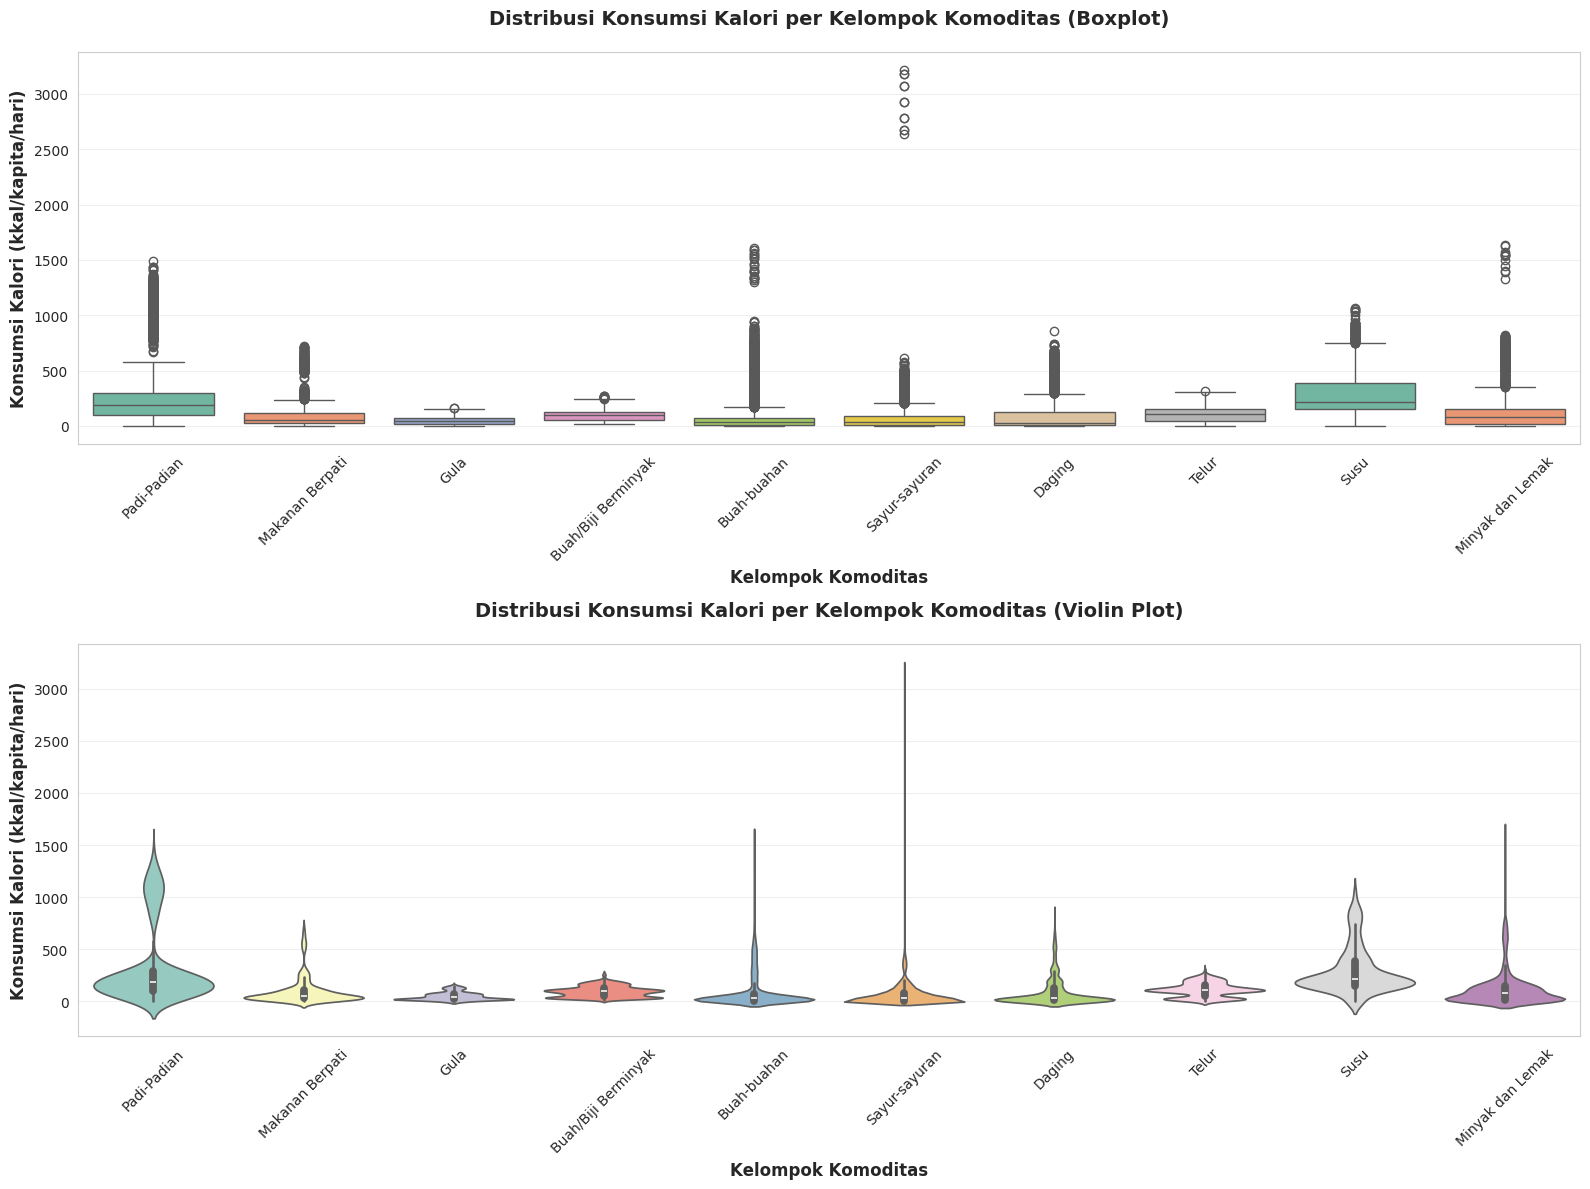

Visualisasi disimpan: distribusi_kelompok.png


In [56]:
print("VISUALISASI DISTRIBUSI KONSUMSI KALORI")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

df_sorted = df.sort_values('kode_kelompok')

ax1 = axes[0]
sns.boxplot(data=df_sorted, x='nama_kelompok', y='kalori_per_capita_per_day',
            palette='Set2', ax=ax1)
ax1.set_title('Distribusi Konsumsi Kalori per Kelompok Komoditas (Boxplot)',
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Kelompok Komoditas', fontsize=12, fontweight='bold')
ax1.set_ylabel('Konsumsi Kalori (kkal/kapita/hari)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
sns.violinplot(data=df_sorted, x='nama_kelompok', y='kalori_per_capita_per_day',
               palette='Set3', ax=ax2)
ax2.set_title('Distribusi Konsumsi Kalori per Kelompok Komoditas (Violin Plot)',
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Kelompok Komoditas', fontsize=12, fontweight='bold')
ax2.set_ylabel('Konsumsi Kalori (kkal/kapita/hari)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('distribusi_kelompok.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualisasi disimpan: distribusi_kelompok.png")

ANALISIS POLA TEMPORAL KONSUMSI KALORI 1993-2024


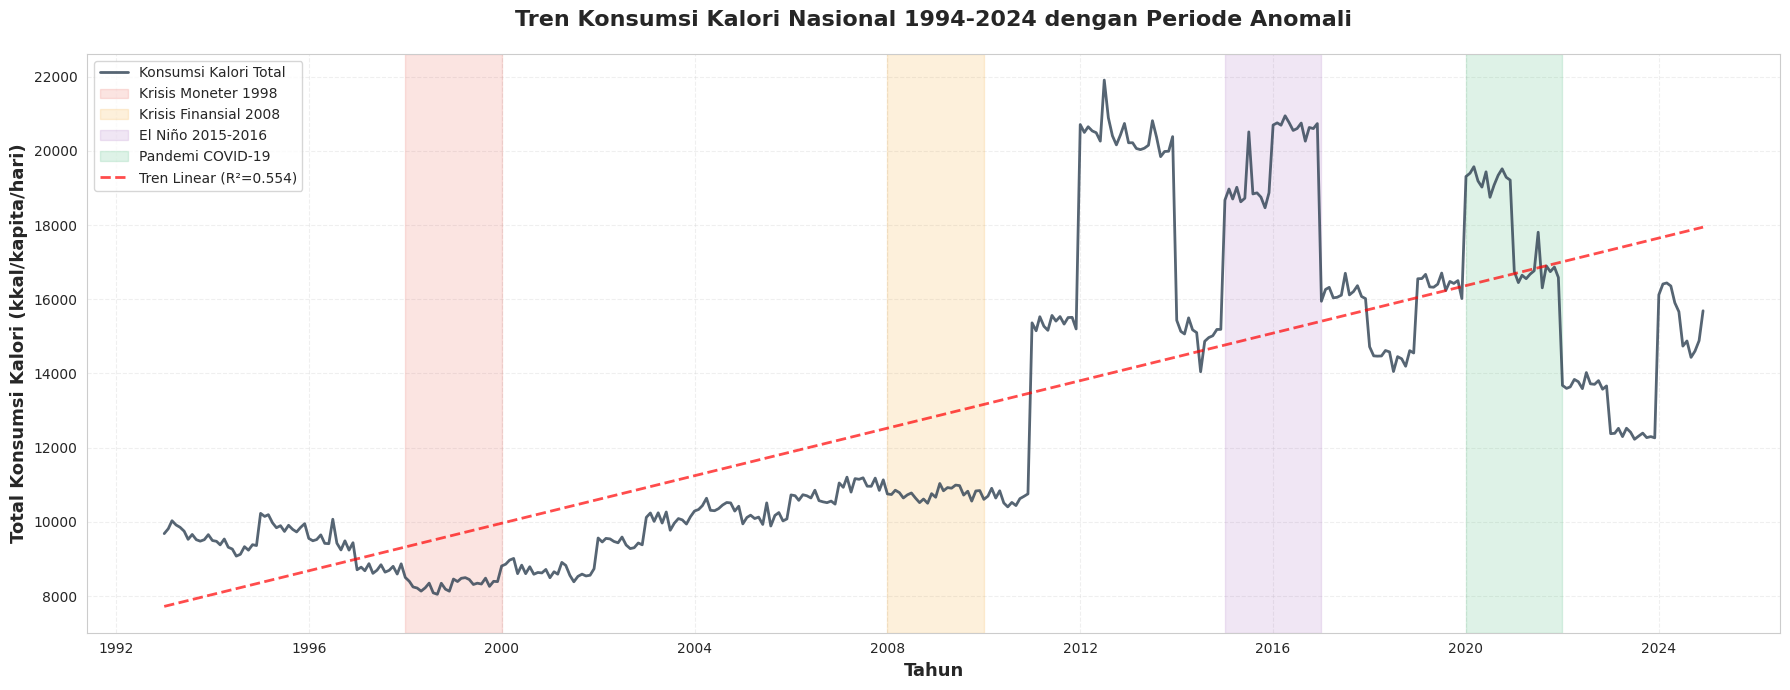


ANALISIS TREN:
   Slope (kenaikan per hari): 0.8768 kkal/hari
   R²: 0.5540
   P-value: 0.000000
   Tren signifikan secara statistik (p < 0.05)

Visualisasi disimpan: time_series_kalori.png


In [57]:
print("ANALISIS POLA TEMPORAL KONSUMSI KALORI 1993-2024")

monthly_kalori = df.groupby(['tahun', 'bulan'])['kalori_per_capita_per_day'].sum().reset_index()
monthly_kalori['date'] = pd.to_datetime(
    monthly_kalori['tahun'].astype(str) + '-' +
    monthly_kalori['bulan'].astype(str).str.zfill(2) + '-01'
)

fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(monthly_kalori['date'], monthly_kalori['kalori_per_capita_per_day'],
        linewidth=2, color='#2C3E50', label='Konsumsi Kalori Total', alpha=0.8)

crisis_periods = {
    'Krisis Moneter 1998': ('1998-01-01', '1999-12-31', '#E74C3C', 0.15),
    'Krisis Finansial 2008': ('2008-01-01', '2009-12-31', '#F39C12', 0.15),
    'El Niño 2015-2016': ('2015-01-01', '2016-12-31', '#9B59B6', 0.15),
    'Pandemi COVID-19': ('2020-01-01', '2021-12-31', '#27AE60', 0.15)
}

for crisis_name, (start, end, color, alpha) in crisis_periods.items():
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
               alpha=alpha, color=color, label=crisis_name)

from scipy.stats import linregress
x_numeric = (monthly_kalori['date'] - monthly_kalori['date'].min()).dt.days
slope, intercept, r_value, p_value, std_err = linregress(x_numeric, monthly_kalori['kalori_per_capita_per_day'])
trendline = slope * x_numeric + intercept
ax.plot(monthly_kalori['date'], trendline,
        linestyle='--', color='red', linewidth=2, label=f'Tren Linear (R²={r_value**2:.3f})', alpha=0.7)

ax.set_title('Tren Konsumsi Kalori Nasional 1994-2024 dengan Periode Anomali',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Tahun', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Konsumsi Kalori (kkal/kapita/hari)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('time_series_kalori.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nANALISIS TREN:")
print(f"   Slope (kenaikan per hari): {slope:.4f} kkal/hari")
print(f"   R²: {r_value**2:.4f}")
print(f"   P-value: {p_value:.6f}")
if p_value < 0.05:
    print(f"   Tren signifikan secara statistik (p < 0.05)")
else:
    print(f"   Tren tidak signifikan (p >= 0.05)")

print("\nVisualisasi disimpan: time_series_kalori.png")

ANALISIS OUTLIERS PER PERIODE KRISIS

Analisis Outliers per Periode Krisis
                Periode  Total Records  Jumlah Outliers  Persentase (%)
    Krisis Moneter Asia           2688              134            4.99
Krisis Finansial Global           2688              293           10.90
                El Niño           3732              384           10.29
       Pandemi COVID-19           3252              363           11.16
    Normal (Non-Krisis)          35460             3186            8.98

Statistik IQR per Periode Krisis
                Periode    Q1     Q3    IQR  Lower Bound  Upper Bound
    Krisis Moneter Asia  5.59 101.85  96.26      -138.80       246.24
Krisis Finansial Global  8.38  94.48  86.10      -120.77       223.63
                El Niño 17.29 155.11 137.82      -189.44       361.85
       Pandemi COVID-19 17.07 154.59 137.52      -189.20       360.86
    Normal (Non-Krisis)  9.96 119.50 109.53      -154.34       283.80

Tabel disimpan: analisis_outliers_kris

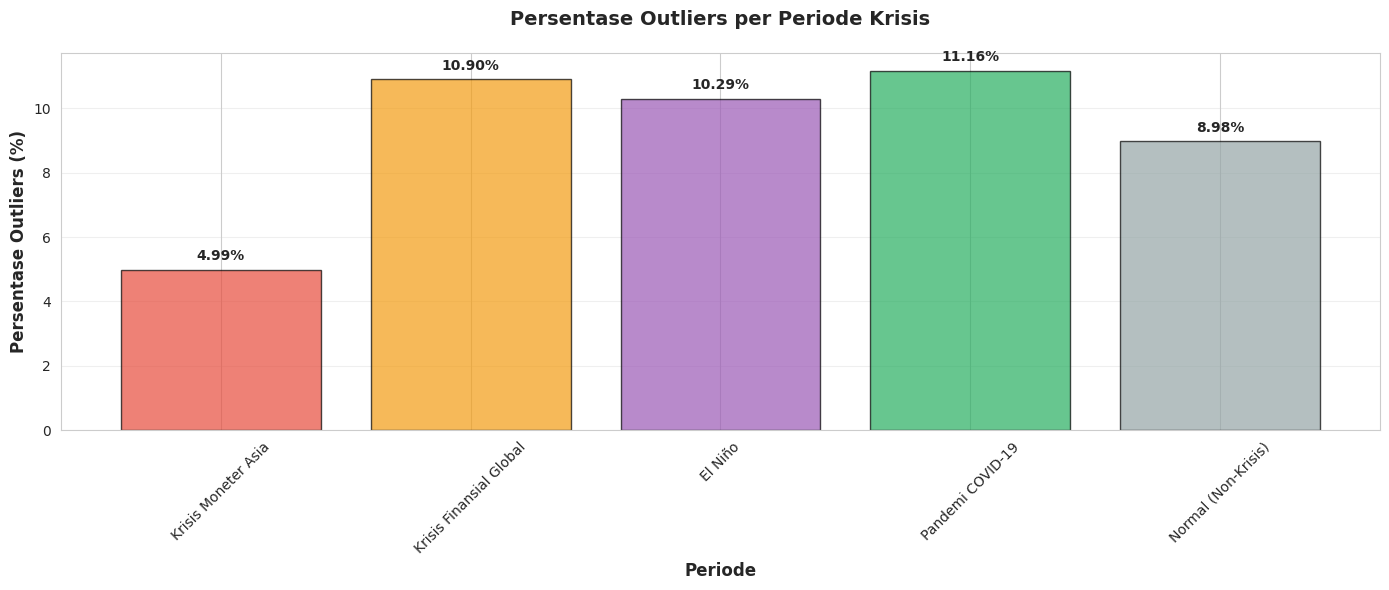


Visualisasi disimpan: outliers_per_krisis.png


In [58]:
print("ANALISIS OUTLIERS PER PERIODE KRISIS")

crisis_periods_detail = {
    'Krisis Moneter Asia': (1998, 1999),
    'Krisis Finansial Global': (2008, 2009),
    'El Niño': (2015, 2016),
    'Pandemi COVID-19': (2020, 2021),
    'Normal (Non-Krisis)': None
}

outlier_summary = []

for crisis_name, period in crisis_periods_detail.items():
    if period is not None:
        start_year, end_year = period
        crisis_data = df[(df['tahun'] >= start_year) & (df['tahun'] <= end_year)].copy()
    else:
        crisis_years = [1998, 1999, 2008, 2009, 2015, 2016, 2020, 2021]
        crisis_data = df[~df['tahun'].isin(crisis_years)].copy()

    Q1 = crisis_data['kalori_per_capita_per_day'].quantile(0.25)
    Q3 = crisis_data['kalori_per_capita_per_day'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = crisis_data[
        (crisis_data['kalori_per_capita_per_day'] < lower_bound) |
        (crisis_data['kalori_per_capita_per_day'] > upper_bound)
    ]

    outlier_summary.append({
        'Periode': crisis_name,
        'Total Records': len(crisis_data),
        'Jumlah Outliers': len(outliers),
        'Persentase (%)': round(len(outliers) / len(crisis_data) * 100, 2) if len(crisis_data) > 0 else 0,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print("\nAnalisis Outliers per Periode Krisis")
print(outlier_df[['Periode', 'Total Records', 'Jumlah Outliers', 'Persentase (%)']].to_string(index=False))

print("\nStatistik IQR per Periode Krisis")
print(outlier_df[['Periode', 'Q1', 'Q3', 'IQR', 'Lower Bound', 'Upper Bound']].to_string(index=False))

outlier_df.to_csv('analisis_outliers_krisis.csv', index=False)
print("\nTabel disimpan: analisis_outliers_krisis.csv")

fig, ax = plt.subplots(figsize=(14, 6))
periods = outlier_df['Periode'].values
percentages = outlier_df['Persentase (%)'].values

colors = ['#E74C3C', '#F39C12', '#9B59B6', '#27AE60', '#95A5A6']
bars = ax.bar(periods, percentages, color=colors, alpha=0.7, edgecolor='black')

ax.set_title('Persentase Outliers per Periode Krisis',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Periode', fontsize=12, fontweight='bold')
ax.set_ylabel('Persentase Outliers (%)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{pct:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('outliers_per_krisis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisasi disimpan: outliers_per_krisis.png")

## **3. Data Preprocessing**

In [59]:
print("PREPROCESSING & FEATURE ENGINEERING")

df['month_sin'] = df['bulan_sin']
df['month_cos'] = df['bulan_cos']
df['quarter_sin'] = df['kuartal_sin']
df['quarter_cos'] = df['kuartal_cos']

df['import_ratio'] = np.where(df['masukan'] > 0, df['impor'] / df['masukan'], 0)
df['export_ratio'] = np.where(df['keluaran'] > 0, df['ekspor'] / df['keluaran'], 0)
df['price_margin'] = np.where(
    (df['harga_konsumen'].notna()) & (df['harga_produsen'].notna()) & (df['harga_produsen'] > 0),
    (df['harga_konsumen'] - df['harga_produsen']) / df['harga_produsen'],
    0
)

df['is_crisis_1998'] = ((df['tahun'] == 1998) | (df['tahun'] == 1999)).astype(int)
df['is_crisis_2008'] = ((df['tahun'] >= 2008) & (df['tahun'] <= 2009)).astype(int)
df['is_el_nino_2015'] = ((df['tahun'] >= 2015) & (df['tahun'] <= 2016)).astype(int)
df['is_pandemic'] = ((df['tahun'] >= 2020) & (df['tahun'] <= 2021)).astype(int)

FEATURE_COLS = [
    'kalori_lag_1', 'kalori_lag_3', 'kalori_lag_6', 'kalori_lag_12',
    'bahan_makanan_lag_1', 'bahan_makanan_lag_3',
    'kalori_ma_3', 'kalori_ma_6', 'kalori_ma_12',
    'kalori_growth_yoy',
    'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos',
    'bahan_makanan', 'masukan', 'keluaran', 'impor', 'ekspor',
    'perubahan_stok',
    'import_ratio', 'export_ratio', 'price_margin',
    'kalori_per_100g', 'protein_per_100g', 'lemak_per_100g', 'karbohidrat_per_100g',
    'is_crisis_1998', 'is_crisis_2008', 'is_el_nino_2015', 'is_pandemic'
]

TARGET_COL = 'kalori_per_capita_per_day'

print(f"\nTotal features: {len(FEATURE_COLS)}")
print(f"Target: {TARGET_COL}")
print(f"\nFeature breakdown:")
print(f"  Time series (lag + MA): 10")
print(f"  Temporal (seasonal): 4")
print(f"  Supply chain: 6")
print(f"  Economic ratios: 3")
print(f"  Nutritional: 4")
print(f"  Crisis indicators: 4")

PREPROCESSING & FEATURE ENGINEERING

Total features: 31
Target: kalori_per_capita_per_day

Feature breakdown:
  Time series (lag + MA): 10
  Temporal (seasonal): 4
  Supply chain: 6
  Economic ratios: 3
  Nutritional: 4
  Crisis indicators: 4


In [60]:
print("Removing rows with missing lag features...")
df_model = df.dropna(subset=['kalori_lag_12', TARGET_COL]).copy()

print(f"After removing NaN lag_12: {len(df_model):,} rows ({len(df) - len(df_model):,} removed)")

for col in FEATURE_COLS:
    if df_model[col].isna().any():
        n_missing = df_model[col].isna().sum()
        print(f"  Filling {n_missing:,} NaN in {col}")
        df_model[col] = df_model[col].fillna(0)

X = df_model[FEATURE_COLS].values
y = df_model[TARGET_COL].values

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nCleaning data...")

inf_mask = np.isinf(X)
if inf_mask.any():
    print(f"  Found {inf_mask.sum()} infinity values")
    X = np.where(inf_mask, 0, X)

n_clipped = 0
for i in range(X.shape[1]):
    col_mean = np.nanmean(X[:, i])
    col_std = np.nanstd(X[:, i])
    if col_std > 0:
        clipped = np.clip(X[:, i], col_mean - 5*col_std, col_mean + 5*col_std)
        n_clipped += np.sum(X[:, i] != clipped)
        X[:, i] = clipped

print(f"Data cleaned ({n_clipped:,} extreme values clipped)")

df_model['X_index'] = range(len(df_model))
print(f"\nReady for train/val/test split with {len(df_model):,} records")

Removing rows with missing lag features...
After removing NaN lag_12: 46,476 rows (1,344 removed)

X shape: (46476, 31)
y shape: (46476,)

Cleaning data...
Data cleaned (4,838 extreme values clipped)

Ready for train/val/test split with 46,476 records


## **4. Split Data**

In [61]:
print("TRAIN/VAL/TEST SPLIT (BY YEAR)")

train_mask = df_model['tahun'] <= 2016
val_mask = (df_model['tahun'] >= 2017) & (df_model['tahun'] <= 2020)
test_mask = df_model['tahun'] >= 2021

train_data = df_model[train_mask]
val_data = df_model[val_mask]
test_data = df_model[test_mask]

train_idx = train_mask.values
val_idx = val_mask.values
test_idx = test_mask.values

X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]

n_total = len(df_model)
print(f"Train: {len(X_train):,} samples ({len(X_train)/n_total*100:.1f}%)")
print(f"Val:   {len(X_val):,} samples ({len(X_val)/n_total*100:.1f}%)")
print(f"Test:  {len(X_test):,} samples ({len(X_test)/n_total*100:.1f}%)")

print(f"\nYear ranges:")
print(f"Train: {int(train_data['tahun'].min())}-{int(train_data['tahun'].max())}")
print(f"Val:   {int(val_data['tahun'].min())}-{int(val_data['tahun'].max())}")
print(f"Test:  {int(test_data['tahun'].min())}-{int(test_data['tahun'].max())}")

print(f"\nTarget distribution:")
print(f"Train: mean={y_train.mean():.2f}, std={y_train.std():.2f}")
print(f"Val:   mean={y_val.mean():.2f}, std={y_val.std():.2f}")
print(f"Test:  mean={y_test.mean():.2f}, std={y_test.std():.2f}")

TRAIN/VAL/TEST SPLIT (BY YEAR)
Train: 34,008 samples (73.2%)
Val:   6,900 samples (14.8%)
Test:  5,568 samples (12.0%)

Year ranges:
Train: 1994-2016
Val:   2017-2020
Test:  2021-2024

Target distribution:
Train: mean=97.46, std=159.67
Val:   mean=115.37, std=162.76
Test:  mean=125.72, std=223.10


In [62]:
df_model_filtered = df_model.copy()

print(f"Data yang digunakan:")
print(f"Total commodities: {df_model_filtered['nama_komoditi'].nunique()}")
print(f"Total records: {len(df_model_filtered):,}")

print(f"\nDistribusi data per tier:")
tier_mayor = (df_model_filtered[TARGET_COL] >= 50).sum()
tier_moderate = ((df_model_filtered[TARGET_COL] >= 10) & (df_model_filtered[TARGET_COL] < 50)).sum()
tier_minor = ((df_model_filtered[TARGET_COL] >= 1) & (df_model_filtered[TARGET_COL] < 10)).sum()
tier_very_minor = (df_model_filtered[TARGET_COL] < 1).sum()

print(f"TIER 1 (≥50 kkal):    {tier_mayor:,} records ({tier_mayor/len(df_model_filtered)*100:.1f}%)")
print(f"TIER 2 (10-50 kkal):  {tier_moderate:,} records ({tier_moderate/len(df_model_filtered)*100:.1f}%)")
print(f"TIER 3 (1-10 kkal):   {tier_minor:,} records ({tier_minor/len(df_model_filtered)*100:.1f}%)")
print(f"TIER 4 (<1 kkal):     {tier_very_minor:,} records ({tier_very_minor/len(df_model_filtered)*100:.1f}%)")

X_filtered = df_model_filtered[FEATURE_COLS].values
y_filtered = df_model_filtered[TARGET_COL].values

train_mask_filtered = df_model_filtered['tahun'] <= 2016
val_mask_filtered = (df_model_filtered['tahun'] >= 2017) & (df_model_filtered['tahun'] <= 2020)
test_mask_filtered = df_model_filtered['tahun'] >= 2021

X_train = X_filtered[train_mask_filtered.values]
y_train = y_filtered[train_mask_filtered.values]
X_val = X_filtered[val_mask_filtered.values]
y_val = y_filtered[val_mask_filtered.values]
X_test = X_filtered[test_mask_filtered.values]
y_test = y_filtered[test_mask_filtered.values]

print(f"\nSplit sizes:")
print(f"Train: {len(X_train):,} samples ({len(X_train)/len(X_filtered)*100:.1f}%)")
print(f"Val:   {len(X_val):,} samples ({len(X_val)/len(X_filtered)*100:.1f}%)")
print(f"Test:  {len(X_test):,} samples ({len(X_test)/len(X_filtered)*100:.1f}%)")

Data yang digunakan:
Total commodities: 112
Total records: 46,476

Distribusi data per tier:
TIER 1 (≥50 kkal):    21,671 records (46.6%)
TIER 2 (10-50 kkal):  13,438 records (28.9%)
TIER 3 (1-10 kkal):   7,509 records (16.2%)
TIER 4 (<1 kkal):     3,858 records (8.3%)

Split sizes:
Train: 34,008 samples (73.2%)
Val:   6,900 samples (14.8%)
Test:  5,568 samples (12.0%)


## **5. Feature Scaling**

In [63]:
print("FEATURE SCALING")

if np.isinf(X_train).any():
    print("Warning: Found infinity in X_train, replacing with 0")
    X_train = np.where(np.isinf(X_train), 0, X_train)
if np.isinf(X_val).any():
    X_val = np.where(np.isinf(X_val), 0, X_val)
if np.isinf(X_test).any():
    X_test = np.where(np.isinf(X_test), 0, X_test)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

print("\nFeatures scaled with StandardScaler")
print(f"Mean: {X_train_scaled.mean():.6f}")
print(f"Std: {X_train_scaled.std():.6f}")

FEATURE SCALING

Features scaled with StandardScaler
Mean: 0.000000
Std: 0.983739


## **6. Model 1: XGBoost**

In [64]:
print("MODEL 1: XGBOOST")

def custom_mape_top_percentile(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    threshold = np.percentile(y_true, 80)
    mask = y_true >= threshold

    if mask.sum() == 0:
        return 0.0

    safe_y_true = np.where(y_true[mask] < 1, 1, y_true[mask])
    mape = np.mean(np.abs((safe_y_true - y_pred[mask]) / safe_y_true)) * 100
    return mape

from sklearn.metrics import make_scorer
mape_scorer = make_scorer(custom_mape_top_percentile, greater_is_better=False)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [2000],
    'max_depth': [12],
    'learning_rate': [0.01],
    'subsample': [0.9],
    'colsample_bytree': [0.9],
    'reg_alpha': [0.01],
    'reg_lambda': [1.0, 2.0]
}

print(f"\nGrid Search Configuration:")
print(f"Combinations: {len(param_grid['reg_lambda'])}")
print(f"CV folds: 2")
print(f"Scoring: MAPE on top 20% kalori values")

base_xgb = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1,
    min_child_weight=3,
    gamma=0.1
)

grid_search = GridSearchCV(
    base_xgb,
    param_grid,
    cv=2,
    scoring=mape_scorer,
    verbose=1,
    n_jobs=-1
)

print("\nTraining XGBoost...")
grid_search.fit(X_train_scaled, y_train)

model_xgb = grid_search.best_estimator_

print(f"\nBest XGBoost parameters:")
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV score (top 20% MAPE): {-grid_search.best_score_:.2f}%")

y_train_pred_xgb = model_xgb.predict(X_train_scaled)
y_val_pred_xgb = model_xgb.predict(X_val_scaled)
y_test_pred_xgb = model_xgb.predict(X_test_scaled)

y_train_pred_xgb = np.clip(y_train_pred_xgb, 0, None)
y_val_pred_xgb = np.clip(y_val_pred_xgb, 0, None)
y_test_pred_xgb = np.clip(y_test_pred_xgb, 0, None)

def calculate_mape(y_true, y_pred):
    mask = y_true > 1
    if mask.sum() == 0:
        return 0.0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_train = calculate_mape(y_train, y_train_pred_xgb)
mape_val = calculate_mape(y_val, y_val_pred_xgb)
mape_test = calculate_mape(y_test, y_test_pred_xgb)

r2_train = r2_score(y_train, y_train_pred_xgb)
r2_val = r2_score(y_val, y_val_pred_xgb)
r2_test = r2_score(y_test, y_test_pred_xgb)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
mae_test = mean_absolute_error(y_test, y_test_pred_xgb)

print(f"\nXGBoost Performance:")
print(f"\nTrain Set:")
print(f"MAPE: {mape_train:.2f}%")
print(f"R²:   {r2_train:.4f}")

print(f"\nValidation Set:")
print(f"MAPE: {mape_val:.2f}%")
print(f"R²:   {r2_val:.4f}")

print(f"\nTest Set (2021-2024):")
print(f"MAPE: {mape_test:.2f}%")
print(f"R²:   {r2_test:.4f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE:  {mae_test:.2f}")

MODEL 1: XGBOOST

Grid Search Configuration:
Combinations: 2
CV folds: 2
Scoring: MAPE on top 20% kalori values

Training XGBoost...
Fitting 2 folds for each of 2 candidates, totalling 4 fits

Best XGBoost parameters:
colsample_bytree: 0.9
learning_rate: 0.01
max_depth: 12
n_estimators: 2000
reg_alpha: 0.01
reg_lambda: 2.0
subsample: 0.9

Best CV score (top 20% MAPE): 7.60%

XGBoost Performance:

Train Set:
MAPE: 1.39%
R²:   1.0000

Validation Set:
MAPE: 5.23%
R²:   0.9835

Test Set (2021-2024):
MAPE: 5.51%
R²:   0.8533
RMSE: 85.44
MAE:  11.35


In [65]:
def calculate_metrics_tiered(y_true, y_pred, name=""):
    y_pred = np.clip(y_pred, 0, None)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{name} - TIERED EVALUATION")

    tiers = {
        'TIER 1 (MAYOR)': (y_true >= 50, 'Komoditi Utama (≥50 kkal)'),
        'TIER 2 (MODERATE)': ((y_true >= 10) & (y_true < 50), 'Komoditi Penting (10-50 kkal)'),
        'TIER 3 (MINOR)': ((y_true >= 1) & (y_true < 10), 'Komoditi Pendukung (1-10 kkal)'),
        'TIER 4 (VERY MINOR)': (y_true < 1, 'Komoditi Kecil (<1 kkal)')
    }

    tier_results = {}

    for tier_name, (mask, desc) in tiers.items():
        if mask.sum() == 0:
            continue

        y_true_tier = y_true[mask]
        y_pred_tier = y_pred[mask]

        rmse_tier = np.sqrt(mean_squared_error(y_true_tier, y_pred_tier))
        mae_tier = mean_absolute_error(y_true_tier, y_pred_tier)
        r2_tier = r2_score(y_true_tier, y_pred_tier)

        safe_y_true = np.maximum(y_true_tier, 0.1)
        mape_tier = np.mean(np.abs((y_true_tier - y_pred_tier) / safe_y_true)) * 100

        importance_weight = np.mean(y_true_tier) / np.mean(y_true) if np.mean(y_true) > 0 else 1.0

        tier_results[tier_name] = {
            'samples': mask.sum(),
            'rmse': rmse_tier,
            'mae': mae_tier,
            'r2': r2_tier,
            'mape': mape_tier,
            'weight': importance_weight,
            'desc': desc
        }

        print(f"\n{tier_name}: {desc}")
        print(f"Samples: {mask.sum():,} ({mask.sum()/len(y_true)*100:.1f}%)")
        print(f"Mean Actual: {np.mean(y_true_tier):.2f} kkal")
        print(f"MAPE: {mape_tier:.2f}%")
        print(f"MAE:  {mae_tier:.2f} kkal")
        print(f"RMSE: {rmse_tier:.2f} kkal")
        print(f"R²:   {r2_tier:.4f}")
        print(f"Importance Weight: {importance_weight:.2f}x")

    weighted_mape_parts = []
    weights = []

    for tier_name, result in tier_results.items():
        if 'TIER 1' in tier_name or 'TIER 2' in tier_name:
            weighted_mape_parts.append(result['mape'])
            weights.append(result['weight'] * result['samples'])

    if len(weighted_mape_parts) > 0:
        weighted_mape = np.average(weighted_mape_parts, weights=weights)
    else:
        weighted_mape = 0.0

    print(f"\nOVERALL METRICS:")
    print(f"RMSE (All): {rmse:.4f}")
    print(f"MAE (All):  {mae:.4f}")
    print(f"R² (All):   {r2:.4f}")
    print(f"WEIGHTED MAPE (Focus Tier 1+2): {weighted_mape:.2f}%")

    return {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'mape': weighted_mape,
        'tier_results': tier_results
    }

print("\nEVALUATING XGBOOST")

y_train_pred_xgb = model_xgb.predict(X_train_scaled)
y_val_pred_xgb = model_xgb.predict(X_val_scaled)
y_test_pred_xgb = model_xgb.predict(X_test_scaled)

xgb_train_metrics = calculate_metrics_tiered(y_train, y_train_pred_xgb, "XGBoost Train")
xgb_val_metrics = calculate_metrics_tiered(y_val, y_val_pred_xgb, "XGBoost Val")
xgb_test_metrics = calculate_metrics_tiered(y_test, y_test_pred_xgb, "XGBoost Test")


EVALUATING XGBOOST
XGBoost Train - TIERED EVALUATION

TIER 1 (MAYOR): Komoditi Utama (≥50 kkal)
Samples: 15,370 (45.2%)
Mean Actual: 195.68 kkal
MAPE: 0.44%
MAE:  0.57 kkal
RMSE: 0.79 kkal
R²:   1.0000
Importance Weight: 2.01x

TIER 2 (MODERATE): Komoditi Penting (10-50 kkal)
Samples: 9,914 (29.2%)
Mean Actual: 28.15 kkal
MAPE: 1.38%
MAE:  0.33 kkal
RMSE: 0.44 kkal
R²:   0.9986
Importance Weight: 0.29x

TIER 3 (MINOR): Komoditi Pendukung (1-10 kkal)
Samples: 5,768 (17.0%)
Mean Actual: 4.64 kkal
MAPE: 3.95%
MAE:  0.16 kkal
RMSE: 0.23 kkal
R²:   0.9906
Importance Weight: 0.05x

TIER 4 (VERY MINOR): Komoditi Kecil (<1 kkal)
Samples: 2,956 (8.7%)
Mean Actual: 0.37 kkal
MAPE: 20.06%
MAE:  0.05 kkal
RMSE: 0.15 kkal
R²:   0.7609
Importance Weight: 0.00x

OVERALL METRICS:
RMSE (All): 0.5930
MAE (All):  0.3860
R² (All):   1.0000
WEIGHTED MAPE (Focus Tier 1+2): 0.52%
XGBoost Val - TIERED EVALUATION

TIER 1 (MAYOR): Komoditi Utama (≥50 kkal)
Samples: 3,587 (52.0%)
Mean Actual: 205.93 kkal
MAPE: 

## **7. Model 2: LSTM**

In [66]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import RobustScaler

print("PREPARING SEQUENTIAL DATA FOR LSTM")

lookback = 6
def create_sequences(X, y, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, lookback)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val, lookback)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, lookback)

print(f"\nSequential data shapes:")
print(f"X_train_seq: {X_train_seq.shape} -> (samples, timesteps, features)")
print(f"y_train_seq: {y_train_seq.shape}")
print(f"X_val_seq:   {X_val_seq.shape}")
print(f"y_val_seq:   {y_val_seq.shape}")
print(f"X_test_seq:  {X_test_seq.shape}")
print(f"y_test_seq:  {y_test_seq.shape}")

scaler_y_lstm = RobustScaler()
y_train_lstm_scaled = scaler_y_lstm.fit_transform(y_train_seq.reshape(-1, 1)).flatten()
y_val_lstm_scaled = scaler_y_lstm.transform(y_val_seq.reshape(-1, 1)).flatten()
y_test_lstm_scaled = scaler_y_lstm.transform(y_test_seq.reshape(-1, 1)).flatten()

print(f"\nTarget scaled - Train mean: {y_train_lstm_scaled.mean():.4f}, std: {y_train_lstm_scaled.std():.4f}")

def build_lstm(input_shape):
    model = keras.Sequential([
        layers.LSTM(128, return_sequences=False, input_shape=input_shape,
                   recurrent_dropout=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.15),

        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.1),

        layers.Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mae',
        metrics=['mae', 'mse']
    )

    return model

model_lstm = build_lstm(input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]))

model_lstm.summary()

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    'best_lstm.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

print("\nTraining LSTM - Max epochs: 150, Batch size: 128")

history_lstm = model_lstm.fit(
    X_train_seq, y_train_lstm_scaled,
    validation_data=(X_val_seq, y_val_lstm_scaled),
    epochs=150,
    batch_size=128,
    callbacks=[early_stop, reduce_lr, model_checkpoint],
    verbose=1
)

print(f"\nTraining complete - Best val_loss: {min(history_lstm.history['val_loss']):.6f}")

# Generate predictions
y_train_pred_scaled = model_lstm.predict(X_train_seq, verbose=0).flatten()
y_val_pred_scaled = model_lstm.predict(X_val_seq, verbose=0).flatten()
y_test_pred_scaled = model_lstm.predict(X_test_seq, verbose=0).flatten()

# Inverse transform to original scale
y_train_pred_lstm = scaler_y_lstm.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
y_val_pred_lstm = scaler_y_lstm.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()
y_test_pred_lstm = scaler_y_lstm.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

# Clip negative predictions
y_train_pred_lstm = np.clip(y_train_pred_lstm, 0, None)
y_val_pred_lstm = np.clip(y_val_pred_lstm, 0, None)
y_test_pred_lstm = np.clip(y_test_pred_lstm, 0, None)

print("\nLSTM predictions generated:")
print(f"Train: {len(y_train_pred_lstm)} predictions (from {len(y_train)} original samples)")
print(f"Val:   {len(y_val_pred_lstm)} predictions (from {len(y_val)} original samples)")
print(f"Test:  {len(y_test_pred_lstm)} predictions (from {len(y_test)} original samples)")

print("\nEvaluating LSTM")

lstm_train = calculate_metrics_tiered(y_train_seq, y_train_pred_lstm, "LSTM Train")
lstm_val = calculate_metrics_tiered(y_val_seq, y_val_pred_lstm, "LSTM Val")
lstm_test = calculate_metrics_tiered(y_test_seq, y_test_pred_lstm, "LSTM Test")

PREPARING SEQUENTIAL DATA FOR LSTM

Sequential data shapes:
X_train_seq: (34002, 6, 31) -> (samples, timesteps, features)
y_train_seq: (34002,)
X_val_seq:   (6894, 6, 31)
y_val_seq:   (6894,)
X_test_seq:  (5562, 6, 31)
y_test_seq:  (5562,)

Target scaled - Train mean: 0.5283, std: 1.5197


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 128)            │        81,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,801 (362.50 KB)

 Trainable params: 92,545 (361.50 KB)

 Non-trainable params: 256 (1.00 KB)


Training LSTM - Max epochs: 150, Batch size: 128
Epoch 1/150
266/266 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - loss: 0.5731 - mae: 0.4528 - mse: 0.8217 - val_loss: 0.5738 - val_mae: 0.4697 - val_mse: 0.6609 - learning_rate: 0.0010
Epoch 2/150
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 0.3271 - mae: 0.2280 - mse: 0.2660 - val_loss: 0.3255 - val_mae: 0.2404 - val_mse: 0.3010 - learning_rate: 0.0010
Epoch 3/150
266/266 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.2867 - mae: 0.2061 - mse: 0.2409 - val_loss: 0.3122 - val_mae: 0.2439 - val_mse: 0.2935 - learning_rate: 0.0010
Epoch 4/150
266/266 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.2613 - mae: 0.1966 - mse: 0.2197 - val_loss: 0.2544 - val_mae: 0.1997 - val_mse: 0.2436 - learning_rate: 0.0010
Epoch 5/150
266/266 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.2373 - mae: 0.1855 - mse: 0.2010 - val_loss: 0.2416 - val_mae: 0.1978 - val_mse: 0.2438 - learning_rate: 0.0010
Epoch 6/150
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.22

## **8. Model 3: HuberRegressor**

In [67]:
print("MODEL 3: HUBER REGRESSOR")

huber_configs = [
    {'epsilon': 1.2, 'max_iter': 5000, 'alpha': 0.000001},
    {'epsilon': 1.25, 'max_iter': 5000, 'alpha': 0.00001},
    {'epsilon': 1.3, 'max_iter': 5000, 'alpha': 0.0001},
]

best_huber_mape = float('inf')
best_huber_model = None
best_huber_config = None

print(f"\nTesting {len(huber_configs)} Huber configurations...")

for i, config in enumerate(huber_configs, 1):
    print(f"\nConfig {i}/{len(huber_configs)}: epsilon={config['epsilon']}, alpha={config['alpha']}")

    model_huber_temp = HuberRegressor(**config)
    model_huber_temp.fit(X_train_scaled, y_train)

    y_val_pred_temp = model_huber_temp.predict(X_val_scaled)

    mask_major = y_val >= 100.0
    mask_moderate = (y_val >= 10.0) & (y_val < 100.0)

    mape_parts = []
    weights = []

    if mask_major.sum() > 0:
        mape_major = np.mean(np.abs((y_val[mask_major] - y_val_pred_temp[mask_major]) / y_val[mask_major])) * 100
        mape_parts.append(mape_major)
        weights.append(mask_major.sum() * 3.0)

    if mask_moderate.sum() > 0:
        mape_moderate = np.mean(np.abs((y_val[mask_moderate] - y_val_pred_temp[mask_moderate]) / y_val[mask_moderate])) * 100
        mape_parts.append(mape_moderate)
        weights.append(mask_moderate.sum() * 1.0)

    val_mape = np.average(mape_parts, weights=weights) if len(mape_parts) > 0 else 0.0

    print(f"Validation MAPE: {val_mape:.2f}%")

    if val_mape < best_huber_mape:
        best_huber_mape = val_mape
        best_huber_model = model_huber_temp
        best_huber_config = config
        print(f"New best!")

model_huber = best_huber_model

print(f"\nBest Huber config: {best_huber_config}")
print(f"Best validation MAPE: {best_huber_mape:.2f}%")


MODEL 3: HUBER REGRESSOR

Testing 3 Huber configurations...

Config 1/3: epsilon=1.2, alpha=1e-06
Validation MAPE: 6.12%
New best!

Config 2/3: epsilon=1.25, alpha=1e-05
Validation MAPE: 6.12%

Config 3/3: epsilon=1.3, alpha=0.0001
Validation MAPE: 6.12%

Best Huber config: {'epsilon': 1.2, 'max_iter': 5000, 'alpha': 1e-06}
Best validation MAPE: 6.12%


In [68]:
print("EVALUATING HUBERREGRESSOR")

y_train_pred_huber = model_huber.predict(X_train_scaled)
y_val_pred_huber = model_huber.predict(X_val_scaled)
y_test_pred_huber = model_huber.predict(X_test_scaled)

huber_train_metrics = calculate_metrics_tiered(y_train, y_train_pred_huber, "HuberRegressor Train")
huber_val_metrics = calculate_metrics_tiered(y_val, y_val_pred_huber, "HuberRegressor Val")
huber_test_metrics = calculate_metrics_tiered(y_test, y_test_pred_huber, "HuberRegressor Test")

EVALUATING HUBERREGRESSOR
HuberRegressor Train - TIERED EVALUATION

TIER 1 (MAYOR): Komoditi Utama (≥50 kkal)
Samples: 15,370 (45.2%)
Mean Actual: 195.68 kkal
MAPE: 5.42%
MAE:  10.44 kkal
RMSE: 27.07 kkal
R²:   0.9810
Importance Weight: 2.01x

TIER 2 (MODERATE): Komoditi Penting (10-50 kkal)
Samples: 9,914 (29.2%)
Mean Actual: 28.15 kkal
MAPE: 5.51%
MAE:  1.51 kkal
RMSE: 2.84 kkal
R²:   0.9404
Importance Weight: 0.29x

TIER 3 (MINOR): Komoditi Pendukung (1-10 kkal)
Samples: 5,768 (17.0%)
Mean Actual: 4.64 kkal
MAPE: 6.78%
MAE:  0.27 kkal
RMSE: 1.01 kkal
R²:   0.8243
Importance Weight: 0.05x

TIER 4 (VERY MINOR): Komoditi Kecil (<1 kkal)
Samples: 2,956 (8.7%)
Mean Actual: 0.37 kkal
MAPE: 483.81%
MAE:  1.24 kkal
RMSE: 12.21 kkal
R²:   -1613.1418
Importance Weight: 0.00x

OVERALL METRICS:
RMSE (All): 18.6183
MAE (All):  5.3137
R² (All):   0.9864
WEIGHTED MAPE (Focus Tier 1+2): 5.43%
HuberRegressor Val - TIERED EVALUATION

TIER 1 (MAYOR): Komoditi Utama (≥50 kkal)
Samples: 3,587 (52.0%)
Me

## **9. Model 4: LSTM Enhanced Ensemble**

In [69]:
print("MODEL 4: LSTM ENHANCED ENSEMBLE")
print("\nAligning predictions from all models...")

print(f"XGBoost predictions:  {len(y_test_pred_xgb)}")
print(f"LSTM predictions:     {len(y_test_pred_lstm)}")
print(f"Huber predictions:    {len(y_test_pred_huber)}")
print(f"Actual test labels:   {len(y_test)}")

min_len_all = min(len(y_test_pred_xgb), len(y_test_pred_lstm),
                  len(y_test_pred_huber), len(y_test))

print(f"\nAligning all to {min_len_all} samples (due to LSTM sequence window)...")

# Align test set
y_test_aligned = y_test[-min_len_all:]
y_pred_xgb_aligned = y_test_pred_xgb[-min_len_all:]
y_pred_lstm_aligned = y_test_pred_lstm[-min_len_all:]
y_pred_huber_aligned = y_test_pred_huber[-min_len_all:]

# Align validation set
if len(y_val_pred_lstm) < len(y_val):
    min_len_val = min(len(y_val_pred_xgb), len(y_val_pred_lstm),
                      len(y_val_pred_huber), len(y_val))
    y_val_aligned = y_val[-min_len_val:]
    y_val_pred_xgb_aligned = y_val_pred_xgb[-min_len_val:]
    y_val_pred_lstm_aligned = y_val_pred_lstm[-min_len_val:]
    y_val_pred_huber_aligned = y_val_pred_huber[-min_len_val:]
else:
    y_val_aligned = y_val
    y_val_pred_xgb_aligned = y_val_pred_xgb
    y_val_pred_lstm_aligned = y_val_pred_lstm
    y_val_pred_huber_aligned = y_val_pred_huber

# Align training set
if len(y_train_pred_lstm) < len(y_train):
    min_len_train = min(len(y_train_pred_xgb), len(y_train_pred_lstm),
                       len(y_train_pred_huber), len(y_train))
    y_train_aligned = y_train[-min_len_train:]
    y_train_pred_xgb_aligned = y_train_pred_xgb[-min_len_train:]
    y_train_pred_lstm_aligned = y_train_pred_lstm[-min_len_train:]
    y_train_pred_huber_aligned = y_train_pred_huber[-min_len_train:]
else:
    y_train_aligned = y_train
    y_train_pred_xgb_aligned = y_train_pred_xgb
    y_train_pred_lstm_aligned = y_train_pred_lstm
    y_train_pred_huber_aligned = y_train_pred_huber

print(f"Train aligned: {len(y_train_aligned)} samples")
print(f"Val aligned:   {len(y_val_aligned)} samples")
print(f"Test aligned:  {len(y_test_aligned)} samples")

MODEL 4: LSTM ENHANCED ENSEMBLE

Aligning predictions from all models...
XGBoost predictions:  5568
LSTM predictions:     5562
Huber predictions:    5568
Actual test labels:   5568

Aligning all to 5562 samples (due to LSTM sequence window)...
Train aligned: 34002 samples
Val aligned:   6894 samples
Test aligned:  5562 samples


In [70]:
print("Finding optimal ensemble weights using validation set...")

best_mape = float('inf')
best_weight_xgb = 0.2
best_weight_lstm = 0.5
best_weight_huber = 0.3

weight_combinations = [
    (0.10, 0.40, 0.50), (0.15, 0.40, 0.45), (0.20, 0.40, 0.40), (0.25, 0.40, 0.35), (0.30, 0.40, 0.30),
    (0.10, 0.45, 0.45), (0.15, 0.45, 0.40), (0.20, 0.45, 0.35), (0.25, 0.45, 0.30), (0.30, 0.45, 0.25),
    (0.10, 0.50, 0.40), (0.15, 0.50, 0.35), (0.20, 0.50, 0.30), (0.25, 0.50, 0.25), (0.30, 0.50, 0.20),
    (0.10, 0.55, 0.35), (0.15, 0.55, 0.30), (0.20, 0.55, 0.25), (0.25, 0.55, 0.20),
    (0.10, 0.60, 0.30), (0.15, 0.60, 0.25), (0.20, 0.60, 0.20),
]

print(f"\nTesting {len(weight_combinations)} weight combinations...")

Finding optimal ensemble weights using validation set...

Testing 22 weight combinations...


In [71]:
print(f"{'XGB':>6} {'LSTM':>6} {'Huber':>6}   {'MAPE':>8}")
print("-" * 35)

for w_xgb, w_lstm, w_huber in weight_combinations:
    y_pred_temp = (w_xgb * y_val_pred_xgb_aligned +
                   w_lstm * y_val_pred_lstm_aligned +
                   w_huber * y_val_pred_huber_aligned)

    mask_important = y_val_aligned >= 10.0

    if mask_important.sum() > 0:
        safe_y_true = np.maximum(y_val_aligned[mask_important], 1.0)
        mape_temp = np.mean(np.abs((y_val_aligned[mask_important] - y_pred_temp[mask_important]) / safe_y_true)) * 100

        print(f"{w_xgb:5.2f}  {w_lstm:5.2f}  {w_huber:5.2f}   {mape_temp:7.2f}%", end="")

        if mape_temp < best_mape:
            best_mape = mape_temp
            best_weight_xgb = w_xgb
            best_weight_lstm = w_lstm
            best_weight_huber = w_huber
            print("  <- Best")
        else:
            print()

   XGB   LSTM  Huber       MAPE
-----------------------------------
 0.10   0.40   0.50      8.95%  <- Best
 0.15   0.40   0.45      8.81%  <- Best
 0.20   0.40   0.40      8.69%  <- Best
 0.25   0.40   0.35      8.57%  <- Best
 0.30   0.40   0.30      8.46%  <- Best
 0.10   0.45   0.45      9.43%
 0.15   0.45   0.40      9.30%
 0.20   0.45   0.35      9.18%
 0.25   0.45   0.30      9.07%
 0.30   0.45   0.25      8.97%
 0.10   0.50   0.40      9.93%
 0.15   0.50   0.35      9.81%
 0.20   0.50   0.30      9.70%
 0.25   0.50   0.25      9.60%
 0.30   0.50   0.20      9.51%
 0.10   0.55   0.35     10.46%
 0.15   0.55   0.30     10.34%
 0.20   0.55   0.25     10.24%
 0.25   0.55   0.20     10.14%
 0.10   0.60   0.30     11.00%
 0.15   0.60   0.25     10.89%
 0.20   0.60   0.20     10.79%


In [72]:
print(f"Optimal weights found:")
print(f"XGBoost:     {best_weight_xgb:5.1%}")
print(f"LSTM:        {best_weight_lstm:5.1%}")
print(f"Huber:       {best_weight_huber:5.1%}")
print(f"Total:       {best_weight_xgb + best_weight_lstm + best_weight_huber:5.1%}")
print(f"\nValidation MAPE: {best_mape:.2f}%")

Optimal weights found:
XGBoost:     30.0%
LSTM:        40.0%
Huber:       30.0%
Total:       100.0%

Validation MAPE: 8.46%


In [73]:
print("Creating ensemble predictions with optimal weights...")

ensemble_train_pred = (best_weight_xgb * y_train_pred_xgb_aligned +
                       best_weight_lstm * y_train_pred_lstm_aligned +
                       best_weight_huber * y_train_pred_huber_aligned)

ensemble_val_pred = (best_weight_xgb * y_val_pred_xgb_aligned +
                     best_weight_lstm * y_val_pred_lstm_aligned +
                     best_weight_huber * y_val_pred_huber_aligned)

y_test_pred_ensemble = (best_weight_xgb * y_pred_xgb_aligned +
                        best_weight_lstm * y_pred_lstm_aligned +
                        best_weight_huber * y_pred_huber_aligned)

print(f"Train ensemble: {len(ensemble_train_pred)} predictions")
print(f"Val ensemble:   {len(ensemble_val_pred)} predictions")
print(f"Test ensemble:  {len(y_test_pred_ensemble)} predictions")

Creating ensemble predictions with optimal weights...
Train ensemble: 34002 predictions
Val ensemble:   6894 predictions
Test ensemble:  5562 predictions


In [74]:
# Hitung ulang metrics untuk data yang sudah aligned
xgb_test_metrics_aligned = calculate_metrics_tiered(
    y_test_aligned, y_pred_xgb_aligned, "XGBoost Test (Aligned)"
)

lstm_test_metrics_aligned = calculate_metrics_tiered(
    y_test_aligned, y_pred_lstm_aligned, "LSTM Test (Aligned)"
)

huber_test_metrics_aligned = calculate_metrics_tiered(
    y_test_aligned, y_pred_huber_aligned, "Huber Test (Aligned)"
)

ensemble_train_metrics = calculate_metrics_tiered(y_train_aligned, ensemble_train_pred, "Ensemble Train")
ensemble_val_metrics = calculate_metrics_tiered(y_val_aligned, ensemble_val_pred, "Ensemble Val")
ensemble_test_metrics = calculate_metrics_tiered(y_test_aligned, y_test_pred_ensemble, "Ensemble Test")

XGBoost Test (Aligned) - TIERED EVALUATION

TIER 1 (MAYOR): Komoditi Utama (≥50 kkal)
Samples: 2,708 (48.7%)
Mean Actual: 238.34 kkal
MAPE: 4.49%
MAE:  21.73 kkal
RMSE: 122.06 kkal
R²:   0.8040
Importance Weight: 1.91x

TIER 2 (MODERATE): Komoditi Penting (10-50 kkal)
Samples: 1,608 (28.9%)
Mean Actual: 28.57 kkal
MAPE: 4.52%
MAE:  1.16 kkal
RMSE: 6.39 kkal
R²:   0.6472
Importance Weight: 0.23x

TIER 3 (MINOR): Komoditi Pendukung (1-10 kkal)
Samples: 862 (15.5%)
Mean Actual: 4.25 kkal
MAPE: 10.47%
MAE:  0.34 kkal
RMSE: 1.05 kkal
R²:   0.8051
Importance Weight: 0.03x

TIER 4 (VERY MINOR): Komoditi Kecil (<1 kkal)
Samples: 384 (6.9%)
Mean Actual: 0.37 kkal
MAPE: 1113.20%
MAE:  4.04 kkal
RMSE: 20.38 kkal
R²:   -3426.2077
Importance Weight: 0.00x

OVERALL METRICS:
RMSE (All): 85.4051
MAE (All):  11.2479
R² (All):   0.8521
WEIGHTED MAPE (Focus Tier 1+2): 4.49%
LSTM Test (Aligned) - TIERED EVALUATION

TIER 1 (MAYOR): Komoditi Utama (≥50 kkal)
Samples: 2,708 (48.7%)
Mean Actual: 238.34 kkal
M

In [75]:
print(f"LSTM ENHANCED ENSEMBLE - RESULTS")

print(f"\nEnsemble Configuration:")
print(f"XGBoost:      {best_weight_xgb:5.1%}")
print(f"LSTM:         {best_weight_lstm:5.1%}")
print(f"Huber:        {best_weight_huber:5.1%}")

print(f"\nTest Set Performance:")
print(f"Weighted MAPE (Tier 1+2): {ensemble_test_metrics['mape']:.2f}%")
print(f"RMSE:                     {ensemble_test_metrics['rmse']:.2f}")
print(f"MAE:                      {ensemble_test_metrics['mae']:.2f}")
print(f"R²:                       {ensemble_test_metrics['r2']:.4f}")

LSTM ENHANCED ENSEMBLE - RESULTS

Ensemble Configuration:
XGBoost:      30.0%
LSTM:         40.0%
Huber:        30.0%

Test Set Performance:
Weighted MAPE (Tier 1+2): 7.46%
RMSE:                     75.97
MAE:                      13.31
R²:                       0.8830


In [76]:
print(f"Individual model comparison (Test Set):")
print(f"{'Model':<20} {'MAPE':>8} {'Contribution'}")
print(f"{'-'*45}")
print(f"{'XGBoost':<20} {xgb_test_metrics_aligned['mape']:7.2f}%  {best_weight_xgb:5.1%}")
print(f"{'LSTM':<20} {lstm_test_metrics_aligned['mape']:7.2f}%  {best_weight_lstm:5.1%}")
print(f"{'Huber':<20} {huber_test_metrics_aligned['mape']:7.2f}%  {best_weight_huber:5.1%}")
print(f"{'-'*45}")
print(f"{'Ensemble':<20} {ensemble_test_metrics['mape']:7.2f}%  100.0%")

Individual model comparison (Test Set):
Model                    MAPE Contribution
---------------------------------------------
XGBoost                 4.49%  30.0%
LSTM                   14.48%  40.0%
Huber                   5.14%  30.0%
---------------------------------------------
Ensemble                7.46%  100.0%


## **10. Model Comparison**

In [82]:
print("MODEL COMPARISON - TEST SET")

comparison = pd.DataFrame([
    {
        'Model': 'XGBoost',
        'MAPE (Weighted)': xgb_test_metrics['mape'],
        'RMSE': xgb_test_metrics['rmse'],
        'MAE': xgb_test_metrics['mae'],
        'R²': xgb_test_metrics['r2']
    },
    {
        'Model': 'LSTM',
        'MAPE (Weighted)': lstm_test['mape'],
        'RMSE': lstm_test['rmse'],
        'MAE': lstm_test['mae'],
        'R²': lstm_test['r2']
    },
    {
        'Model': 'HuberRegressor',
        'MAPE (Weighted)': huber_test_metrics['mape'],
        'RMSE': huber_test_metrics['rmse'],
        'MAE': huber_test_metrics['mae'],
        'R²': huber_test_metrics['r2']
    },
    {
        'Model': 'LSTM Enhanced Ensemble',
        'MAPE (Weighted)': ensemble_test_metrics['mape'],
        'RMSE': ensemble_test_metrics['rmse'],
        'MAE': ensemble_test_metrics['mae'],
        'R²': ensemble_test_metrics['r2']
    }
])

comparison_display = comparison.copy()
comparison_display['MAPE (Weighted)'] = comparison_display['MAPE (Weighted)'].apply(lambda x: f"{x:.2f}%")
comparison_display['RMSE'] = comparison_display['RMSE'].apply(lambda x: f"{x:.4f}")
comparison_display['MAE'] = comparison_display['MAE'].apply(lambda x: f"{x:.4f}")
comparison_display['R²'] = comparison_display['R²'].apply(lambda x: f"{x:.4f}")

print("\nOverall performance (Weighted MAPE fokus Tier 1+2):")
print(comparison_display.to_string(index=False))

# Hitung improvement dari LSTM ke Ensemble
lstm_mape = comparison.loc[comparison['Model'] == 'LSTM', 'MAPE (Weighted)'].values[0]
ensemble_mape = comparison.loc[comparison['Model'] == 'LSTM Enhanced Ensemble', 'MAPE (Weighted)'].values[0]
improvement = lstm_mape - ensemble_mape
improvement_pct = (improvement / lstm_mape) * 100

print(f"\n✨ LSTM Enhancement Results:")
print(f"LSTM alone:                      {lstm_mape:.2f}% MAPE")
print(f"LSTM Enhanced Ensemble:          {ensemble_mape:.2f}% MAPE")
print(f"Improvement:                     {improvement:.2f}% ({improvement_pct:.1f}% reduction)")
print(f"\nEnsemble composition: XGBoost (30%) + LSTM (40%) + Huber (30%)")
print(f"XGBoost and Huber successfully enhanced LSTM performance!")

comparison.to_csv('model_comparison_test.csv', index=False)
print("\nTable saved: model_comparison_test.csv")

MODEL COMPARISON - TEST SET

Overall performance (Weighted MAPE fokus Tier 1+2):
                 Model MAPE (Weighted)     RMSE     MAE     R²
               XGBoost           4.51%  85.4409 11.3508 0.8533
                  LSTM          14.48% 137.8332 25.3735 0.6148
        HuberRegressor           5.15%  48.7395  7.7634 0.9523
LSTM Enhanced Ensemble           7.46%  75.9719 13.3068 0.8830

✨ LSTM Enhancement Results:
LSTM alone:                      14.48% MAPE
LSTM Enhanced Ensemble:          7.46% MAPE
Improvement:                     7.02% (48.5% reduction)

Ensemble composition: XGBoost (30%) + LSTM (40%) + Huber (30%)
XGBoost and Huber successfully enhanced LSTM performance!

Table saved: model_comparison_test.csv


## **11. Evaluation**

VISUALIZATION: LSTM ENHANCEMENT COMPARISON

Data for visualization:
                    Model       MAPE        RMSE        MAE        R²
0                    LSTM  14.479889  137.833231  25.373531  0.614793
1  LSTM Enhanced Ensemble   7.459761   75.971904  13.306828  0.882971


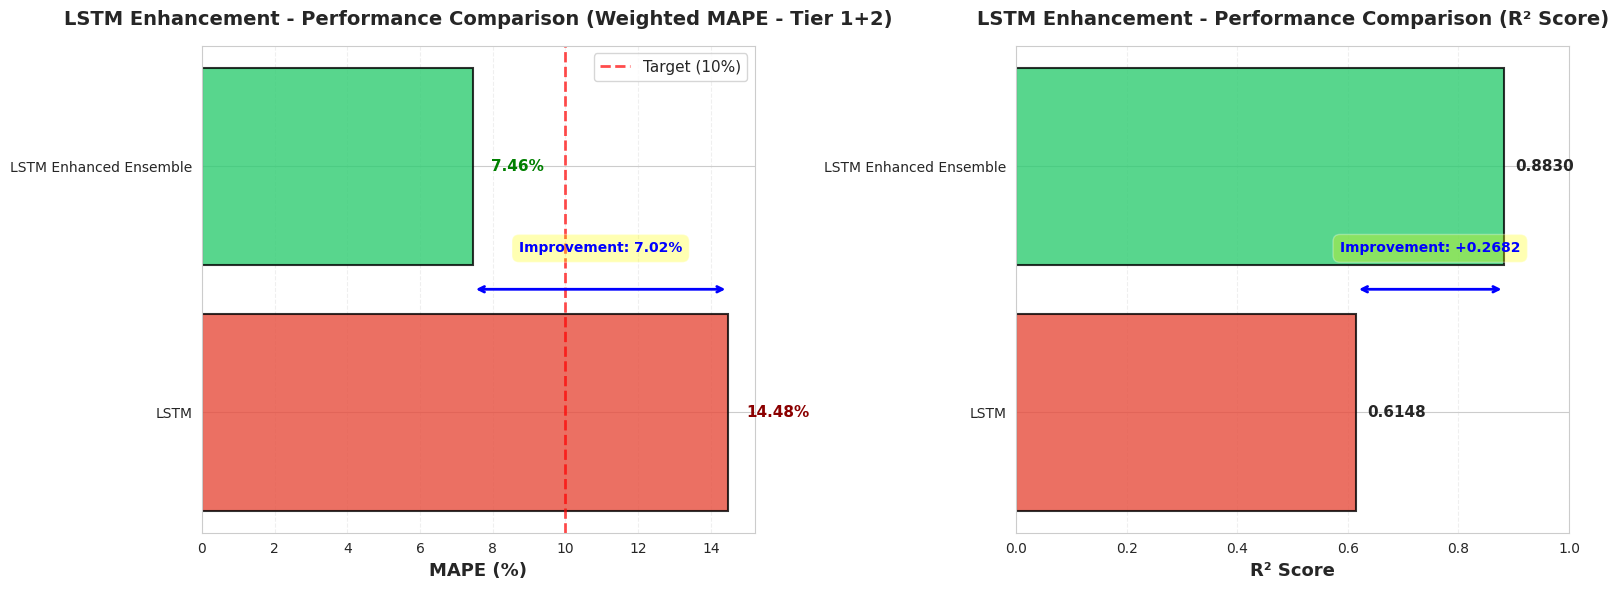


LSTM Enhancement comparison saved: lstm_enhancement_comparison.png

✨ Enhancement Summary:
LSTM alone:              14.48% MAPE, R²=0.6148
LSTM Enhanced Ensemble:  7.46% MAPE, R²=0.8830
MAPE Improvement:        7.02% (48.5% reduction)
R² Improvement:          +0.2682


In [83]:
print("VISUALIZATION: LSTM ENHANCEMENT COMPARISON")

models_list = []
mapes_list = []
rmses_list = []
maes_list = []
r2s_list = []

# Hanya LSTM dan Ensemble
models_data = [
    ('LSTM', lstm_test),
    ('LSTM Enhanced Ensemble', ensemble_test_metrics)
]

for model_name, metrics in models_data:
    models_list.append(model_name)
    mapes_list.append(metrics['mape'])
    rmses_list.append(metrics['rmse'])
    maes_list.append(metrics['mae'])
    r2s_list.append(metrics['r2'])

comparison_viz = pd.DataFrame({
    'Model': models_list,
    'MAPE': mapes_list,
    'RMSE': rmses_list,
    'MAE': maes_list,
    'R²': r2s_list
})

print("\nData for visualization:")
print(comparison_viz)

# Visualisasi MAPE & R² comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
models = comparison_viz['Model'].values
mapes = comparison_viz['MAPE'].values
colors = ['#e74c3c', '#2ecc71']  # Merah untuk LSTM, Hijau untuk Enhanced

bars = ax1.barh(models, mapes, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Target (10%)', alpha=0.7)
ax1.set_xlabel('MAPE (%)', fontsize=13, fontweight='bold')
ax1.set_title('LSTM Enhancement - Performance Comparison (Weighted MAPE - Tier 1+2)',
              fontsize=14, fontweight='bold', pad=15)
ax1.legend(fontsize=11)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, mape) in enumerate(zip(bars, mapes)):
    color = 'green' if mape < 10 else 'darkred'
    ax1.text(mape + 0.5, i, f'{mape:.2f}%', va='center', fontweight='bold',
             fontsize=11, color=color)

# Highlight improvement dengan panah
improvement = mapes[0] - mapes[1]
ax1.annotate('', xy=(mapes[1], 0.5), xytext=(mapes[0], 0.5),
            arrowprops=dict(arrowstyle='<->', color='blue', lw=2))
ax1.text((mapes[0] + mapes[1])/2, 0.65, f'Improvement: {improvement:.2f}%',
         ha='center', fontsize=10, fontweight='bold', color='blue',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

ax2 = axes[1]
r2_scores = comparison_viz['R²'].values
bars2 = ax2.barh(models, r2_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('R² Score', fontsize=13, fontweight='bold')
ax2.set_title('LSTM Enhancement - Performance Comparison (R² Score)',
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, r2) in enumerate(zip(bars2, r2_scores)):
    ax2.text(r2 + 0.02, i, f'{r2:.4f}', va='center', fontweight='bold', fontsize=11)

# Highlight improvement
r2_improvement = r2_scores[1] - r2_scores[0]
ax2.annotate('', xy=(r2_scores[1], 0.5), xytext=(r2_scores[0], 0.5),
            arrowprops=dict(arrowstyle='<->', color='blue', lw=2))
ax2.text((r2_scores[0] + r2_scores[1])/2, 0.65, f'Improvement: +{r2_improvement:.4f}',
         ha='center', fontsize=10, fontweight='bold', color='blue',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('lstm_enhancement_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nLSTM Enhancement comparison saved: lstm_enhancement_comparison.png")

# Summary
improvement_pct = ((mapes[0] - mapes[1]) / mapes[0]) * 100
print(f"\n✨ Enhancement Summary:")
print(f"LSTM alone:              {mapes[0]:.2f}% MAPE, R²={r2_scores[0]:.4f}")
print(f"LSTM Enhanced Ensemble:  {mapes[1]:.2f}% MAPE, R²={r2_scores[1]:.4f}")
print(f"MAPE Improvement:        {mapes[0] - mapes[1]:.2f}% ({improvement_pct:.1f}% reduction)")
print(f"R² Improvement:          +{r2_improvement:.4f}")

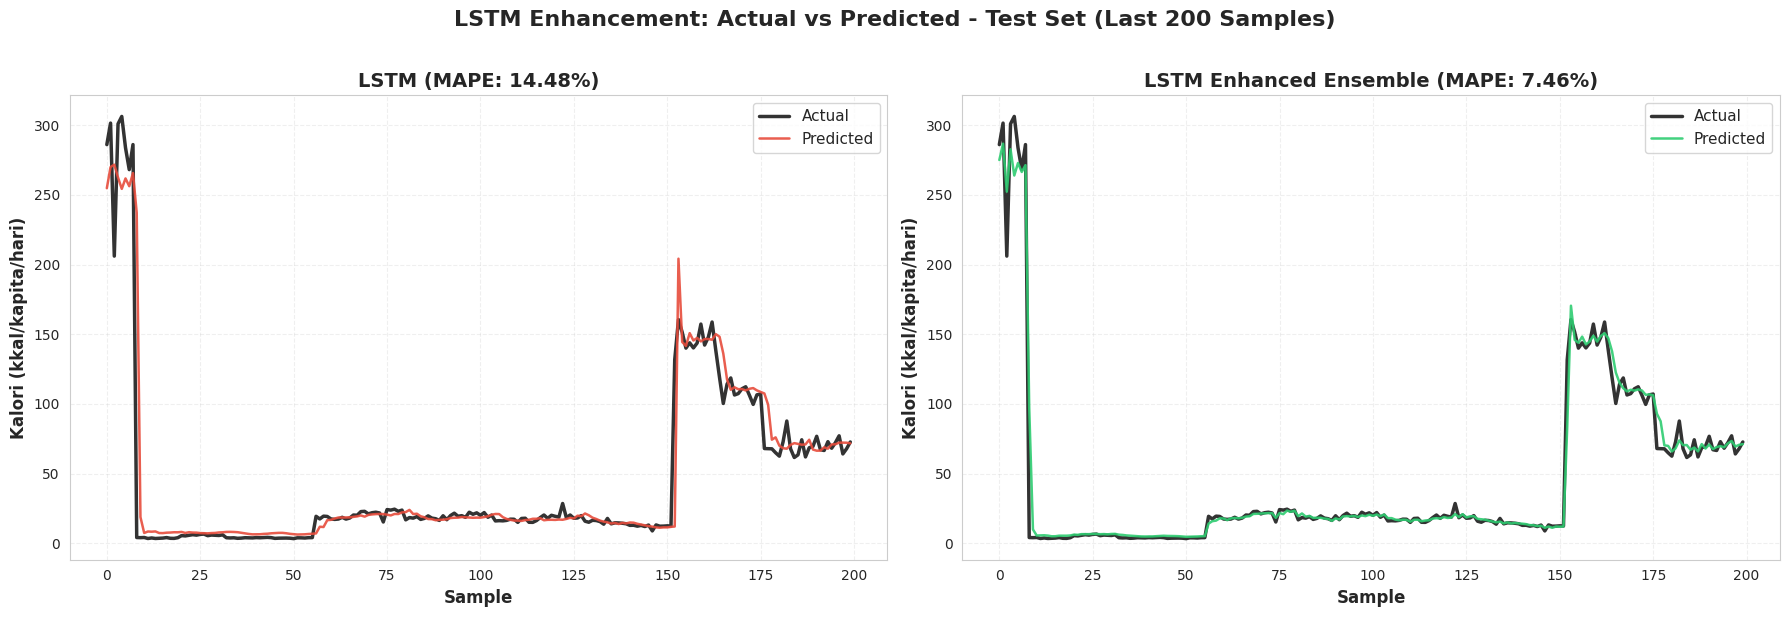


LSTM Enhancement predictions visualization saved: lstm_enhancement_predictions.png

✨ Enhancement Results:
MAPE Improvement: 7.02% (48.5% reduction)


In [84]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

n_samples = min(200, len(y_test_aligned))
indices = range(n_samples)

# LSTM
ax = axes[0]
ax.plot(indices, y_test_aligned[-n_samples:], label='Actual', color='black', linewidth=2.5, alpha=0.8)
ax.plot(indices, y_test_pred_lstm[-n_samples:], label='Predicted', color='#e74c3c', linewidth=1.8, alpha=0.9)
ax.set_title(f'LSTM (MAPE: {lstm_test["mape"]:.2f}%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample', fontsize=12, fontweight='bold')
ax.set_ylabel('Kalori (kkal/kapita/hari)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3, linestyle='--')

# LSTM Enhanced Ensemble
ax = axes[1]
ax.plot(indices, y_test_aligned[-n_samples:], label='Actual', color='black', linewidth=2.5, alpha=0.8)
ax.plot(indices, y_test_pred_ensemble[-n_samples:], label='Predicted', color='#2ecc71', linewidth=1.8, alpha=0.9)
ax.set_title(f'LSTM Enhanced Ensemble (MAPE: {ensemble_test_metrics["mape"]:.2f}%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample', fontsize=12, fontweight='bold')
ax.set_ylabel('Kalori (kkal/kapita/hari)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3, linestyle='--')

plt.suptitle('LSTM Enhancement: Actual vs Predicted - Test Set (Last 200 Samples)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('lstm_enhancement_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nLSTM Enhancement predictions visualization saved: lstm_enhancement_predictions.png")

# Improvement summary
improvement = lstm_test["mape"] - ensemble_test_metrics["mape"]
improvement_pct = (improvement / lstm_test["mape"]) * 100
print(f"\n✨ Enhancement Results:")
print(f"MAPE Improvement: {improvement:.2f}% ({improvement_pct:.1f}% reduction)")

## **12. Prediksi**

In [86]:
print("CREATING PREDICTION FUNCTION")

def predict_kalori(features, model_type='ensemble'):
    """
    Predict kalori using specified model

    Parameters:
    -----------
    features : pd.Series or array-like
        Feature values (31 features)
    model_type : str
        'lstm', 'ensemble'

    Returns:
    --------
    float : predicted kalori value
    """
    # Convert to numpy array if needed
    if isinstance(features, pd.Series):
        X = features.values.reshape(1, -1)
    else:
        X = np.array(features).reshape(1, -1)

    # Scale features
    X_scaled = scaler_X.transform(X)

    if model_type == 'lstm':
        # LSTM needs sequence input (lookback=6)
        # For single prediction, repeat the same features 6 times
        X_seq = np.repeat(X_scaled, lookback, axis=0).reshape(1, lookback, -1)

        # Predict with LSTM
        pred_scaled = model_lstm.predict(X_seq, verbose=0).flatten()[0]

        # Inverse transform
        pred = scaler_y_lstm.inverse_transform([[pred_scaled]])[0][0]

    elif model_type == 'ensemble':
        # LSTM prediction
        X_seq = np.repeat(X_scaled, lookback, axis=0).reshape(1, lookback, -1)
        pred_lstm_scaled = model_lstm.predict(X_seq, verbose=0).flatten()[0]
        pred_lstm = scaler_y_lstm.inverse_transform([[pred_lstm_scaled]])[0][0]

        # XGBoost prediction
        pred_xgb = model_xgb.predict(X_scaled)[0]

        # Huber prediction
        pred_huber = model_huber.predict(X_scaled)[0]

        # Ensemble with optimal weights
        pred = (best_weight_xgb * pred_xgb +
                best_weight_lstm * pred_lstm +
                best_weight_huber * pred_huber)

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    # Clip negative values
    pred = max(0, pred)

    return pred

print("Prediction function created!")
print(f"\nAvailable models:")
print(f"- 'lstm': LSTM only")
print(f"- 'ensemble': LSTM Enhanced Ensemble (XGBoost 30% + LSTM 40% + Huber 30%)")

CREATING PREDICTION FUNCTION
Prediction function created!

Available models:
- 'lstm': LSTM only
- 'ensemble': LSTM Enhanced Ensemble (XGBoost 30% + LSTM 40% + Huber 30%)


In [87]:
print("\nFORECASTING - PREDIKSI MASA DEPAN")

komoditi_terbaru = df_clean.groupby(['kode_kelompok', 'kode_komoditi']).tail(1)

print(f"Total komoditi tersedia: {len(komoditi_terbaru)}")

filtered = komoditi_terbaru[komoditi_terbaru['kode_komoditi'] == 1004]
if len(filtered) == 0:
    print(f"\nKomoditi 1004 tidak ditemukan, menggunakan komoditi pertama")
    filtered = komoditi_terbaru.head(1)

latest_data = filtered.iloc[0]

print(f"\nData terakhir yang tersedia:")
print(f"Komoditi:        {latest_data['nama_komoditi']}")
print(f"Kode Komoditi:   {latest_data['kode_komoditi']}")
print(f"Tahun:           {int(latest_data['tahun'])}")
print(f"Bulan:           {int(latest_data['bulan'])}")
print(f"Kalori Terakhir: {latest_data[TARGET_COL]:.2f} kkal/kapita/hari")

next_month = int(latest_data['bulan']) + 1
next_year = int(latest_data['tahun'])
if next_month > 12:
    next_month = 1
    next_year += 1

print(f"\nPrediksi bulan berikutnya:")
print(f"Target:          {next_year}-{next_month:02d}")

feature_values = {}
for col in FEATURE_COLS:
    feature_values[col] = latest_data[col]

feature_values['tahun'] = next_year
feature_values['bulan'] = next_month

future_features = pd.Series(feature_values)[FEATURE_COLS]

print(f"Features shape: {future_features.shape} (expected: {len(FEATURE_COLS)})")
print(f"Features count: {len(future_features)}")

pred_lstm = predict_kalori(future_features, 'lstm')
pred_ensemble = predict_kalori(future_features, 'ensemble')

print(f"\nLSTM:                      {pred_lstm:7.2f} kkal/kapita/hari")
print(f"LSTM Enhanced Ensemble:    {pred_ensemble:7.2f} kkal/kapita/hari")

# Hitung improvement
improvement = abs(pred_ensemble - pred_lstm)
print(f"Difference:                {improvement:7.2f} kkal/kapita/hari")

print(f"\n\nMulti-step forecast (3 bulan ke depan):")
print(f"{'Bulan':<12} {'LSTM':>12} {'Enhanced':>12} {'Difference':>12}")
print("-" * 50)

for i in range(1, 4):
    m = (int(latest_data['bulan']) + i - 1) % 12 + 1
    y = int(latest_data['tahun']) + ((int(latest_data['bulan']) + i - 1) // 12)

    feat_values = {}
    for col in FEATURE_COLS:
        feat_values[col] = latest_data[col]

    feat_values['tahun'] = y
    feat_values['bulan'] = m

    current_features = pd.Series(feat_values)[FEATURE_COLS]

    p_lstm = predict_kalori(current_features, 'lstm')
    p_ens = predict_kalori(current_features, 'ensemble')
    diff = abs(p_ens - p_lstm)

    print(f"{y}-{m:02d}      {p_lstm:12.2f} {p_ens:12.2f} {diff:12.2f}")

print(f"\n\nPrediksi beberapa komoditi penting (Bulan berikutnya):")
print(f"{'Komoditi':<35} {'Last Actual':>12} {'LSTM':>12} {'Enhanced':>12} {'Change':>10}")
print("-" * 85)

for idx in range(min(5, len(komoditi_terbaru))):
    try:
        latest = komoditi_terbaru.iloc[idx]

        nm = int(latest['bulan']) + 1
        ny = int(latest['tahun'])
        if nm > 12:
            nm = 1
            ny += 1

        feat_vals = {}
        for col in FEATURE_COLS:
            feat_vals[col] = latest[col]

        feat_vals['tahun'] = ny
        feat_vals['bulan'] = nm

        feat = pd.Series(feat_vals)[FEATURE_COLS]

        pred_lstm_k = predict_kalori(feat, 'lstm')
        pred_ens_k = predict_kalori(feat, 'ensemble')
        actual = latest[TARGET_COL]
        change = ((pred_ens_k - actual) / actual * 100) if actual > 0 else 0

        sign = "↑" if change > 0 else "↓"
        nama = str(latest['nama_komoditi'])[:34]
        print(f"{nama:<35} {actual:12.2f} {pred_lstm_k:12.2f} {pred_ens_k:12.2f} {sign} {abs(change):7.2f}%")
    except Exception as e:
        print(f"Error on commodity {idx}: {str(e)[:50]}")
        continue

print("\n✨ LSTM Enhancement Benefits:")
print("The ensemble combines XGBoost (30%) + LSTM (40%) + Huber (30%)")
print("This provides more stable and accurate predictions compared to LSTM alone")

print("\nInterpretasi:")
print("Prediksi ini dapat digunakan untuk:")
print("- Perencanaan distribusi bahan pangan")
print("- Antisipasi kekurangan kalori per kapita")
print("- Kebijakan impor/ekspor jangka pendek")
print("- Early warning system ketahanan pangan")


FORECASTING - PREDIKSI MASA DEPAN
Total komoditi tersedia: 112

Data terakhir yang tersedia:
Komoditi:        Minyak Goreng Sawit
Kode Komoditi:   1004
Tahun:           2024
Bulan:           12
Kalori Terakhir: 258.95 kkal/kapita/hari

Prediksi bulan berikutnya:
Target:          2025-01
Features shape: (31,) (expected: 31)
Features count: 31

LSTM:                       244.53 kkal/kapita/hari
LSTM Enhanced Ensemble:     247.57 kkal/kapita/hari
Difference:                   3.05 kkal/kapita/hari


Multi-step forecast (3 bulan ke depan):
Bulan                LSTM     Enhanced   Difference
--------------------------------------------------
2025-01            244.53       247.57         3.05
2025-02            244.53       247.57         3.05
2025-03            244.53       247.57         3.05


Prediksi beberapa komoditi penting (Bulan berikutnya):
Komoditi                             Last Actual         LSTM     Enhanced     Change
------------------------------------------------------

## **12. Save Models**

In [89]:
print("SAVING LSTM ENHANCED ENSEMBLE MODEL")

import os
os.makedirs('models', exist_ok=True)
os.makedirs('models/ensemble', exist_ok=True)

# Save individual models (diperlukan untuk ensemble)
joblib.dump(model_xgb, 'models/ensemble/xgboost_component.joblib')
print("✓ XGBoost component saved: models/ensemble/xgboost_component.joblib")

model_lstm.save('models/ensemble/lstm_component.keras')
print("✓ LSTM component saved: models/ensemble/lstm_component.keras")

joblib.dump(model_huber, 'models/ensemble/huber_component.joblib')
print("✓ Huber component saved: models/ensemble/huber_component.joblib")

# Save scalers
joblib.dump(scaler_X, 'models/ensemble/scaler_X.joblib')
joblib.dump(scaler_y_lstm, 'models/ensemble/scaler_y_lstm.joblib')
print("✓ Scalers saved: scaler_X.joblib, scaler_y_lstm.joblib")

# Save metadata untuk tracking dan dokumentasi
metadata = {
    'model_name': 'LSTM Enhanced Ensemble',
    'version': '1.0',
    'training_date': datetime.now().isoformat(),
    'dataset_info': {
        'n_samples': int(len(df_clean)),
        'n_features': len(FEATURE_COLS),
        'date_range': f"{df_clean['tahun'].min()}-{df_clean['tahun'].max()}",
        'n_commodities': int(df_clean['kode_komoditi'].nunique())
    },
    'model_architecture': {
        'ensemble_weights': {
            'xgboost': float(best_weight_xgb),
            'lstm': float(best_weight_lstm),
            'huber': float(best_weight_huber)
        },
        'lstm_lookback': int(lookback),
        'lstm_layers': 'LSTM(128) + Dense(64) + Dense(32) + Dense(1)'
    },
    'feature_names': FEATURE_COLS,
    'target_variable': TARGET_COL,
    'performance_metrics': {
        'test_mape': float(ensemble_test_metrics['mape']),
        'test_rmse': float(ensemble_test_metrics['rmse']),
        'test_mae': float(ensemble_test_metrics['mae']),
        'test_r2': float(ensemble_test_metrics['r2']),
        'lstm_improvement': float(lstm_test['mape'] - ensemble_test_metrics['mape'])
    },
    'individual_model_performance': {
        'xgboost_mape': float(xgb_test_metrics['mape']),
        'lstm_mape': float(lstm_test['mape']),
        'huber_mape': float(huber_test_metrics['mape'])
    },
    'target_achieved': bool(ensemble_test_metrics["mape"] < 10.0),
    'notes': 'Ensemble combines XGBoost, LSTM, and Huber for robust predictions'
}

with open('models/ensemble/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✓ Metadata saved: models/ensemble/metadata.json")

# Save feature configuration untuk input validation di FastAPI
feature_config = {
    'feature_names': FEATURE_COLS,
    'feature_count': len(FEATURE_COLS),
    'feature_description': {
        'lag_features': ['kalori_lag_1', 'kalori_lag_3', 'kalori_lag_6', 'kalori_lag_12',
                        'bahan_makanan_lag_1', 'bahan_makanan_lag_3'],
        'moving_average': ['kalori_ma_3', 'kalori_ma_6', 'kalori_ma_12'],
        'temporal': ['month_sin', 'month_cos', 'quarter_sin', 'quarter_cos'],
        'supply_chain': ['bahan_makanan', 'masukan', 'keluaran', 'impor', 'ekspor', 'perubahan_stok'],
        'economic': ['import_ratio', 'export_ratio', 'price_margin'],
        'nutritional': ['kalori_per_100g', 'protein_per_100g', 'lemak_per_100g', 'karbohidrat_per_100g'],
        'crisis': ['is_crisis_1998', 'is_crisis_2008', 'is_el_nino_2015', 'is_pandemic']
    },
    'target_variable': TARGET_COL
}

with open('models/ensemble/feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)
print("✓ Feature config saved: models/ensemble/feature_config.json")

# Create ensemble wrapper class untuk FastAPI
class LSTMEnhancedEnsemble:
    """
    LSTM Enhanced Ensemble Model
    Combines XGBoost (30%) + LSTM (40%) + Huber (30%)
    """
    def __init__(self, xgb_model, lstm_model, huber_model,
                 scaler_X, scaler_y_lstm,
                 weight_xgb, weight_lstm, weight_huber,
                 lookback=6):
        self.xgb_model = xgb_model
        self.lstm_model = lstm_model
        self.huber_model = huber_model
        self.scaler_X = scaler_X
        self.scaler_y_lstm = scaler_y_lstm
        self.weight_xgb = weight_xgb
        self.weight_lstm = weight_lstm
        self.weight_huber = weight_huber
        self.lookback = lookback

    def predict(self, X):
        """
        Predict with ensemble model

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Input features

        Returns:
        --------
        array : predictions
        """
        # Scale features
        X_scaled = self.scaler_X.transform(X)

        # XGBoost prediction
        pred_xgb = self.xgb_model.predict(X_scaled)

        # LSTM prediction (needs sequence)
        n_samples = X_scaled.shape[0]
        X_seq = np.repeat(X_scaled, self.lookback, axis=0).reshape(n_samples, self.lookback, -1)
        pred_lstm_scaled = self.lstm_model.predict(X_seq, verbose=0).flatten()
        pred_lstm = self.scaler_y_lstm.inverse_transform(pred_lstm_scaled.reshape(-1, 1)).flatten()

        # Huber prediction
        pred_huber = self.huber_model.predict(X_scaled)

        # Ensemble prediction
        predictions = (self.weight_xgb * pred_xgb +
                      self.weight_lstm * pred_lstm +
                      self.weight_huber * pred_huber)

        # Clip negative values
        return np.clip(predictions, 0, None)

    def predict_single(self, features):
        """
        Predict single sample

        Parameters:
        -----------
        features : pd.Series or array-like
            Single sample features

        Returns:
        --------
        float : prediction
        """
        if isinstance(features, pd.Series):
            X_input = features.values.reshape(1, -1)
        else:
            X_input = np.array(features).reshape(1, -1)

        return self.predict(X_input)[0]

# Create ensemble instance
ensemble_model = LSTMEnhancedEnsemble(
    xgb_model=model_xgb,
    lstm_model=model_lstm,
    huber_model=model_huber,
    scaler_X=scaler_X,
    scaler_y_lstm=scaler_y_lstm,
    weight_xgb=best_weight_xgb,
    weight_lstm=best_weight_lstm,
    weight_huber=best_weight_huber,
    lookback=lookback
)

# Save ensemble model
joblib.dump(ensemble_model, 'models/ensemble/lstm_enhanced_ensemble.joblib')
print("✓ Ensemble model saved: models/ensemble/lstm_enhanced_ensemble.joblib")

# Create README untuk dokumentasi
readme_content = f"""# LSTM Enhanced Ensemble Model

## Model Information
- **Model Name**: LSTM Enhanced Ensemble
- **Version**: 1.0
- **Training Date**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
- **Performance**: MAPE {ensemble_test_metrics['mape']:.2f}%, R² {ensemble_test_metrics['r2']:.4f}

## Model Architecture
This ensemble combines three models:
- **XGBoost** (30%): Gradient boosting for robust predictions
- **LSTM** (40%): Time series patterns and temporal dependencies
- **HuberRegressor** (30%): Outlier-resistant linear predictions

## Files Structure
```
models/ensemble/
├── lstm_enhanced_ensemble.joblib   # Main ensemble model
├── xgboost_component.joblib        # XGBoost component
├── lstm_component.keras            # LSTM component
├── huber_component.joblib          # Huber component
├── scaler_X.joblib                 # Feature scaler
├── scaler_y_lstm.joblib            # Target scaler for LSTM
├── metadata.json                   # Training metadata
├── feature_config.json             # Feature configuration
└── README.md                       # This file
```

## Usage in FastAPI
```python
import joblib
import numpy as np

# Load model
model = joblib.load('models/ensemble/lstm_enhanced_ensemble.joblib')

# Predict single sample
prediction = model.predict_single(features)

# Predict batch
predictions = model.predict(X)
```

## Input Features ({len(FEATURE_COLS)} features)
The model requires {len(FEATURE_COLS)} features in this exact order:
{chr(10).join([f'{i+1}. {feat}' for i, feat in enumerate(FEATURE_COLS)])}

## Performance Metrics (Test Set 2021-2024)
- **MAPE**: {ensemble_test_metrics['mape']:.2f}%
- **RMSE**: {ensemble_test_metrics['rmse']:.2f}
- **MAE**: {ensemble_test_metrics['mae']:.2f}
- **R²**: {ensemble_test_metrics['r2']:.4f}

## Retraining Workflow
1. Admin updates raw data in `transaksi_nbms` table
2. Python script processes data to generate processed dataset
3. Retrain model with new data
4. Save updated model files
5. FastAPI automatically loads new model
6. Laravel web displays updated predictions

## Notes
- Model expects scaled input (will be handled by embedded scaler)
- Predictions are clipped to non-negative values
- LSTM component uses lookback window of {lookback} timesteps
"""

with open('models/ensemble/README.md', 'w') as f:
    f.write(readme_content)
print("✓ README saved: models/ensemble/README.md")

print("\n" + "="*60)
print("✅ LSTM ENHANCED ENSEMBLE MODEL SAVED SUCCESSFULLY")
print("="*60)
print(f"\nModel Location: models/ensemble/")
print(f"\nFiles saved:")
print(f"  1. lstm_enhanced_ensemble.joblib  - Main model")
print(f"  2. xgboost_component.joblib       - XGBoost ({best_weight_xgb:.0%})")
print(f"  3. lstm_component.keras           - LSTM ({best_weight_lstm:.0%})")
print(f"  4. huber_component.joblib         - Huber ({best_weight_huber:.0%})")
print(f"  5. scaler_X.joblib                - Feature scaler")
print(f"  6. scaler_y_lstm.joblib           - LSTM target scaler")
print(f"  7. metadata.json                  - Model metadata")
print(f"  8. feature_config.json            - Feature configuration")
print(f"  9. README.md                      - Documentation")

print(f"\nModel Performance:")
print(f"  MAPE: {ensemble_test_metrics['mape']:.2f}%")
print(f"  R²:   {ensemble_test_metrics['r2']:.4f}")
print(f"  RMSE: {ensemble_test_metrics['rmse']:.2f}")
print(f"  MAE:  {ensemble_test_metrics['mae']:.2f}")

print(f"\n💡 Next Steps:")
print(f"  1. Integrate with FastAPI endpoint")
print(f"  2. Connect to Laravel web interface")
print(f"  3. Set up automatic retraining pipeline")
print(f"  4. Monitor model performance in production")

SAVING LSTM ENHANCED ENSEMBLE MODEL
✓ XGBoost component saved: models/ensemble/xgboost_component.joblib
✓ LSTM component saved: models/ensemble/lstm_component.keras
✓ Huber component saved: models/ensemble/huber_component.joblib
✓ Scalers saved: scaler_X.joblib, scaler_y_lstm.joblib
✓ Metadata saved: models/ensemble/metadata.json
✓ Feature config saved: models/ensemble/feature_config.json
✓ Ensemble model saved: models/ensemble/lstm_enhanced_ensemble.joblib
✓ README saved: models/ensemble/README.md

✅ LSTM ENHANCED ENSEMBLE MODEL SAVED SUCCESSFULLY

Model Location: models/ensemble/

Files saved:
  1. lstm_enhanced_ensemble.joblib  - Main model
  2. xgboost_component.joblib       - XGBoost (30%)
  3. lstm_component.keras           - LSTM (40%)
  4. huber_component.joblib         - Huber (30%)
  5. scaler_X.joblib                - Feature scaler
  6. scaler_y_lstm.joblib           - LSTM target scaler
  7. metadata.json                  - Model metadata
  8. feature_config.json          